# 태양풍 속도 예측 — P10 · SpeedNet

**출처 논문:** Abraham‐Alowonle, Hamada, Abdelwahab, Kusano & Mahrous (2026),
*"Deep Learning‐Based Prediction of High‐Speed Solar Wind Streams: Spatio‐Temporal
Dependencies in Coronal Hole Dynamics"*, Earth and Space Science 13, e2025EA004523.

논문의 **아키텍처·알고리즘·방식만** 가져와 이 대회의 출력(12 horizon × 6h)에 맞춘다.
데이터·기간·타깃은 전부 대회 것을 쓴다.

---

## 논문에서 가져온 것

| # | 논문 | 논문 위치 | 이 노트북 |
|---|---|---|---|
| 1 | **Stonyhurst 일면좌표 투영** — off-limb 제거 → 경위도 격자로 역투영 → 적도 정렬 crop → 리샘플 | §2.1, Fig. 4b–e | 셀 6. `stonyhurst_sampler` |
| 2 | **로그 변환 + 데이터셋 고정 상수 표준화** (instance-wise 금지) | §2.1 Eq. 1 | 셀 6. `LOG_MEAN/LOG_STD` |
| 3 | **동적 임계 코로나홀 이진맵** (Milošić et al. 2023) | §2.1 Fig. 4f | 셀 6. `dynamic_threshold` |
| 4 | **다채널 EUV 맵 스택** | §2.2 Eq. 2 | 셀 6. `[193, 211, BM]` 3채널 |
| 5 | **SpeedNet 아키텍처** — Conv 블록 4개(Conv+MaxPool+ReLU) → LSTM → FFNN → 출력 | §3, Fig. 7 | 셀 12. `SpeedNet` |
| 6 | **하이퍼파라미터** LSTM 100 / FFNN 200 / Adam / lr 1e-4 / MSE / 100 epoch | Table 4 | 셀 2. `PAPER_FAITHFUL` |
| 7 | **meta-learning 체크포인트** — 검증 손실 최소 시점 저장 | §3 | 셀 16. `train_run` |
| 8 | **backward mapping (가변 지연 정렬)** | §2.3 Fig. 5a | 셀 8. 탄도 정렬 (기존 자산과 통합) |
| 9 | **연속 블록 5-fold 교차검증** (무작위 분할 금지) | §2.3 Fig. 5b | 셀 16. 사슬 단위 폴드 |
| 10 | **중앙자오선 ±10° 지배 가설** (IG attribution 결론) | §4.3, §5 | 셀 8. `MERIDIAN_HALF_WIDTH_DEG` |
| 11 | **Threat Score** (HSE 탐지력) | §3.2 Eq. 11 | 셀 14. `threat_score` |
| 12 | **Grad-CAM 귀인** | §3.1 Eq. 5–6 | 셀 22 (선택 진단) |

## 가져오지 않은 것과 이유

| 논문 항목 | 제외 이유 |
|---|---|
| 171 Å / 304 Å 채널 | 대회 데이터에 없다 (193·211 만 제공). 3번째 채널은 **BM** 으로 채운다 (논문 Eq. 2 의 스택 구조는 유지) |
| ICME(CME) 날짜 제거 (Richardson & Cane 목록) | **외부 데이터 = 실격.** 통계적 이상치 처리로도 대체하지 않는다 (P7 EDA: 윈도우 오염 1.47%, 기준 5% 미만) |
| 27일 / N일 persistence 기준선 | 입력이 120h 뿐이라 27일 전 값을 만들 수 없다 |
| 태양주기 위상별 개별 모델 (ascending/max/declining/min) | 대회 분할이 위상이 아니라 **연중 월** 기준이다 (train 1–8월 / val 9월 / test 10–12월). 위상 라벨은 외부 지식 |
| SW 속도를 입력에서 배제한 설계 | 논문의 장점(운영 적용성)이지만 대회는 wind 20개를 **주고** 6h RMSE 를 채점한다. 6h 는 지속성이 지배하므로 배제하면 손해다 (셀 12 `SpeedNetHybrid` 참조) |
| B0 (태양 자전축 기울기, ±7.25°) 보정 | 천체력이 필요 = **외부 데이터**. `B0 = 0` 으로 고정한다. §6 에 영향 분석 |

## Stonyhurst 투영이 왜 중요한가 — 이 대회 한정 이득

P3~P7 의 코로나홀 격자는 **이미지 픽셀 좌표를 그대로 등분**한 것이다. 그건 정사영(orthographic)이라
경도 φ 에서의 면적이 `cos φ` 만큼 **단축**된다. φ=60° 에서 실제 면적의 절반으로 세어 왔다.

경위도 격자로 역투영하면

1. **면적이 진짜 일면 면적이 된다** — 극·림 근처의 과소 계수가 사라진다
2. **태양 자전이 순수한 가로 평행이동이 된다** — 6h 당 정확히 3.30° (Carrington 14.18°/일 회귀율)
3. **마지막 관측 이후를 외삽할 수 있다** — 지금 동쪽 경도 −φ 에 있는 코로나홀은 `φ/Ω` 시간 뒤
   중앙자오선을 지난다. P7 은 탄도 인덱스를 19 로 clamp 해서 이 구간이 **죽어 있었다**
   (HANDOFF §9: "P3 의 v=700 은 60h 이상에서 인덱스가 19 로 clamp 되어 완전히 죽어 있었다")
4. **논문의 "중앙자오선 ±10°" 결론을 그대로 쓸 수 있다** — 픽셀 좌표에서는 정의할 수 없던 양이다

## 판단 기준 (HANDOFF §10 유지)

- 채택 판단은 **train 사슬 CV** 로만 한다. validation(9월) 은 최종 확인 1회
- 3 km/s 이하 차이는 노이즈로 본다
- 기준선은 **P3 (Public 58.8028)**. 이기지 못하면 제출하지 않는다
- 사다리(셀 16)는 P7 최종형에서 시작해 논문 요소를 **하나씩만** 얹는다. 지면 거기서 멈춘다

## 1. 설정

`PAPER_FAITHFUL = True` 로 두면 논문 Table 4 의 하이퍼파라미터를 그대로 쓴다
(LSTM 100 / FFNN 200 / Adam / lr 1e-4 / batch 12 / MSE / 100 epoch / dropout 없음).

**다만 기본값은 `False` 다.** 논문의 학습 표본은 일 1장 × 10년 = 약 1,060개로 서로 거의 독립인데,
이 대회의 9,607 샘플은 6h stride 슬라이딩 윈도우라 연속 샘플이 입력의 19/20 을 공유한다.
실질 독립 표본은 **태양 자전 약 135회전분**뿐이다. 논문 설정을 그대로 쓰면 1 epoch 이
독립 데이터 20회 통과에 해당해 과적합이 즉시 일어난다. 차이는 셀 16 사다리에서 측정한다.

In [1]:
from pathlib import Path
import gc, json, math, os, random, time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset

SEED = 777
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATA_ROOT_CANDIDATES = [
    Path(os.getenv("SW_DATA_ROOT", "")) if os.getenv("SW_DATA_ROOT") else None,
    Path("public_dataset/competition_dataset_6h"),
    Path("/home/jovyan/public_dataset/competition_dataset_6h"),
    Path("public/public_dataset/competition_dataset_6h"),
    Path("/home/jovyan/public/public_dataset/competition_dataset_6h"),
    Path("dataset"), Path("/home/jovyan/dataset"),
]
DATA_ROOT = None
for candidate in DATA_ROOT_CANDIDATES:
    if candidate is not None and (candidate / "train/inputs.csv").exists():
        DATA_ROOT = candidate
        break
if DATA_ROOT is None:
    raise FileNotFoundError("데이터 경로 없음")

WORK_DIR = Path("work")
CACHE_ROOT = WORK_DIR / "cache"
OUTPUT_DIR = WORK_DIR / "outputs_p8"
SUBMISSION_DIR = Path("submission")
for directory in (CACHE_ROOT, OUTPUT_DIR, SUBMISSION_DIR):
    directory.mkdir(parents=True, exist_ok=True)

IMAGE_COLUMNS = [f"image_{i:02d}" for i in range(20)]
WIND_COLUMNS = [f"wind_{i:02d}" for i in range(20)]
TARGET_COLUMNS = [f"target_{i:02d}" for i in range(12)]
HORIZONS = np.arange(1, 13) * 6          # 6h .. 72h
CHANNELS = ("193", "211")
AU_KM = 1.496e8
STEP_HOURS = 6.0

# ── 논문 §2.1 Stonyhurst 투영 ────────────────────────────────────────────────
PROJ_CODE_VERSION = "p8a"    # 추출 코드를 고치면 반드시 올릴 것 (캐시 오재사용 방지)
MAP_LAT, MAP_LON = 60, 120   # 투영 맵 해상도. 논문은 256x256, 여기서는 계산량에 맞춰 축소
LAT_RANGE_DEG = 60.0         # ±60° 위도. 극 코로나홀은 지구 방향 태양풍과 무관 (HANDOFF §5.4)
LON_RANGE_DEG = 60.0         # ±60° 경도. 림(±90°) 근처는 역투영이 발산한다
B0_DEG = 0.0                 # 태양 자전축 기울기. 천체력 = 외부 데이터라 0 으로 고정
DISK_MARGIN = 0.995          # 원반 검출 반지름 대비 사용 비율. 투영이 림을 이미 잘라낸다
SIDEREAL_DEG_PER_HOUR = 14.18 / 24.0   # Carrington 자전율 → 6h 당 3.545°

# ── 논문 §2.1 동적 임계 (Milošić et al. 2023 계열) ──────────────────────────
# 임계 = 계수 × (투영 맵의 중앙값). 정확한 계수는 논문이 인용만 하고 값을 싣지 않았다.
# P7 EDA 가 이 데이터에서 0.45 를 최적으로 측정했으므로 그 값을 중심으로 3단계를 둔다.
CH_CUTS = (0.30, 0.45, 0.60)
BRIGHT_CUT = 1.60            # 활성영역. P7 EDA: corr +0.128 (반대 부호)
BM_CHANNEL = "and"           # "and" | "193" | "211". P7 EDA: 211 ≈ AND ≫ 193

# ── 코로나홀 면적 격자 ──────────────────────────────────────────────────────
FINE_GRID = (12, 30)         # (위도 10°, 경도 4°). MAP_LAT/MAP_LON 을 정확히 나눈다
CH_GRID = (6, 3)             # 집계 격자. P7 EDA + Collin 2025: 위도 세분, 경도 축소
FOLD_LATITUDE = True         # 적도 대칭 밴드 합산 (B0=0 이므로 남북 구분이 학습 불가능)
USE_LEVELS = ("ch0.45", "bright")

# ── 탄도 정렬 (P7 자산) + 논문 §4.3 중앙자오선 ──────────────────────────────
REFERENCE_TRANSIT_HOURS = 108.0                 # P7 EDA 실측 최대상관 지연
TRANSIT_SPEEDS = (315.0, 345.0, 385.0, 435.0, 500.0, 600.0)
BALLISTIC_OFFSETS = (-4, -2, 0, 2)              # 소스 시각 ±1일 (6h 스텝)
BALLISTIC_SOURCE = "window"                     # "window" = 기준속도 +- offset / "speeds" = 속도별 점
MERIDIAN_HALF_WIDTH_DEG = 10.0                  # 논문 §4.3: 중앙자오선 ±10° 가 지배 소스
USE_ROTATION_EXTRAPOLATION = True               # 마지막 관측 이후는 자전으로 경도 외삽

# ── 모델 ────────────────────────────────────────────────────────────────────
MODEL_VARIANT = "hybrid"     # "euv" | "bm" | "hybrid" | "feature"
#   euv     : 논문 SpeedNet-EUV. 다채널 EUV 맵만 입력
#   bm      : 논문 SpeedNet-BM.  코로나홀 이진맵만 입력 (논문에서 최고 성능)
#   hybrid  : SpeedNet CNN-LSTM + wind 분기 + 탄도 피처. 대회 제출용
#   feature : 맵 없이 격자 피처만 (P7 계열. CNN 없는 대조군)
MAP_CHANNELS = ("193", "211", "bm")   # 논문 Eq. 2 의 3채널 스택 (171/304 자리를 BM 이 대체)

SPEEDNET_FILTERS = (32, 64, 128, 128) # 논문 Fig. 7: Conv 블록 4개, 깊이 증가
SPEEDNET_KERNEL = 3
SPEEDNET_POOL = (3, 7)                # 마지막 adaptive pool. None 이면 conv 출력 그대로
LSTM_UNITS = 100                      # 논문 Table 4
FFNN_UNITS = 200                      # 논문 Table 4 (SpeedNet-EUV). BM 은 400
CH_HIDDEN = 64
CH_BIDIRECTIONAL = True
GATHER_DIM = 16
HORIZON_EMBED = 8
DROPOUT = 0.4                         # 논문에는 없다. 슬라이딩 윈도우 과적합 대책
RESIDUAL_OUTPUT = True                # target - wind_19 를 학습. 논문에는 없는 대회 적응
VERBOSE_MODEL = True

# ── 학습 ────────────────────────────────────────────────────────────────────
PAPER_FAITHFUL = False       # True 면 아래 5줄이 논문 Table 4 값으로 덮어써진다
BATCH_SIZE = 64
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-3
LOSS_KIND = "metric"         # "metric" = horizon별 RMSE 평균(대회 지표) | "mse" = 논문
CV_EPOCHS = 30

if PAPER_FAITHFUL:
    BATCH_SIZE, LEARNING_RATE, WEIGHT_DECAY = 12, 1e-4, 0.0
    LOSS_KIND, CV_EPOCHS, DROPOUT = "mse", 100, 0.0
    RESIDUAL_OUTPUT = False

GRAD_CLIP = 1.0
NUM_WORKERS = 4
LOSS_EPSILON = 1e-8
LOSS_SCALE = 100.0
N_FOLDS = 5
AUGMENT = True
AUG_CH_NOISE = 0.05
AUG_MAP_GAIN = 0.05          # 밝기 지터
AUG_MAP_SHIFT = 2            # 경위도 평행이동 (맵 픽셀). 20프레임 공통
# 좌우 반전은 금지 — 태양 자전 방향(동→서)이 뒤집혀 물리가 깨진다 (HANDOFF §5.7)

# ── HSS / Threat Score (논문 §3.2) ──────────────────────────────────────────
HSE_THRESHOLD = 50.0         # km/s. 논문: "전일 평균 대비 50 km/s 증가"
HSE_LOOKBACK = 4             # 6h × 4 = 24h ("전일") 로 환산

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
PIN_MEMORY = DEVICE.type == "cuda"
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True

print("PyTorch:", torch.__version__, "| device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("data:", DATA_ROOT.resolve())
print(f"투영 맵 {MAP_LAT}x{MAP_LON} (위도 ±{LAT_RANGE_DEG:.0f}°, 경도 ±{LON_RANGE_DEG:.0f}°), "
      f"자전 {SIDEREAL_DEG_PER_HOUR * STEP_HOURS:.2f}°/step")
print(f"variant={MODEL_VARIANT}, paper_faithful={PAPER_FAITHFUL}, loss={LOSS_KIND}")

PyTorch: 2.5.1+cu124 | device: cuda
GPU: NVIDIA A100-SXM4-40GB
data: /home/jovyan/public_dataset/competition_dataset_6h
투영 맵 60x120 (위도 ±60°, 경도 ±60°), 자전 3.54°/step
variant=hybrid, paper_faithful=False, loss=metric


## 2. 데이터 로드 · 시간축 복원

논문 §2.3 은 "결측 없는 연속 20일 구간"을 배치 단위로 잡아 폴드를 나눈다(Fig. 5b).
같은 일을 하려면 **어느 프레임이 어느 프레임 뒤에 오는지**를 알아야 하는데, `inputs.csv` 에는
타임스탬프가 없고 **행 순서도 시간 순서가 아니다** (P7 EDA 확인).

한 행의 `image_00..image_19` 가 연속 20시점이라는 사실만으로 프레임 사슬을 복원한다.
복원된 사슬이 곧 논문의 "연속 구간"이고, 셀 16 CV 폴드의 단위가 된다.

In [2]:
train_inputs = pd.read_csv(DATA_ROOT / "train/inputs.csv")
train_targets_frame = pd.read_csv(DATA_ROOT / "train/targets.csv")
val_inputs = pd.read_csv(DATA_ROOT / "validation/inputs.csv")
val_targets_frame = pd.read_csv(DATA_ROOT / "validation/targets.csv")
test_inputs = pd.read_csv(DATA_ROOT / "test/inputs.csv")
assert train_inputs.sample_id.tolist() == train_targets_frame.sample_id.tolist()
assert val_inputs.sample_id.tolist() == val_targets_frame.sample_id.tolist()


def fill_wind(inputs):
    wind = inputs[WIND_COLUMNS].to_numpy(np.float64)
    valid = np.isfinite(wind).astype(np.float32)
    frame = pd.DataFrame(wind).ffill(axis=1).bfill(axis=1)
    filled = frame.to_numpy(np.float32)
    return np.nan_to_num(filled, nan=float(np.nanmedian(wind))), valid


train_wind, train_wind_valid = fill_wind(train_inputs)
val_wind, val_wind_valid = fill_wind(val_inputs)
test_wind, test_wind_valid = fill_wind(test_inputs)
train_targets = train_targets_frame[TARGET_COLUMNS].to_numpy(np.float32)
val_targets = val_targets_frame[TARGET_COLUMNS].to_numpy(np.float32)


def reconstruct_frame_chains(inputs):
    """이미지 파일명만으로 프레임 시간축을 복원한다. 행 순서에 의존하지 않는다."""
    images = inputs[IMAGE_COLUMNS].to_numpy()
    successor, predecessor, conflicts = {}, {}, 0
    for row in images:
        for current, following in zip(row[:-1], row[1:]):
            if successor.setdefault(current, following) != following:
                conflicts += 1
            if predecessor.setdefault(following, current) != current:
                conflicts += 1
    names = set(images.ravel().tolist())
    chains, visited = [], set()
    for head in sorted(names - set(predecessor)):
        chain, node = [], head
        while node is not None and node not in visited:
            visited.add(node); chain.append(node); node = successor.get(node)
        chains.append(chain)
    assert conflicts == 0 and not (names - visited), "사슬 복원 실패"
    return chains


def sample_chain_index(inputs, chains):
    """샘플이 속한 사슬 번호와 사슬 내 시작 위치."""
    position = {name: (c, o)
                for c, chain in enumerate(chains) for o, name in enumerate(chain)}
    first = inputs[IMAGE_COLUMNS[0]].to_numpy()
    return (np.array([position[n][0] for n in first]),
            np.array([position[n][1] for n in first]))


TRAIN_CHAINS = reconstruct_frame_chains(train_inputs)
VAL_CHAINS = reconstruct_frame_chains(val_inputs)
TEST_CHAINS = reconstruct_frame_chains(test_inputs)
TRAIN_CHAIN_ID, TRAIN_OFFSET = sample_chain_index(train_inputs, TRAIN_CHAINS)

# 사슬 단위 파일 목록 (시간 순). 캐시 인덱스의 기준이 된다.
train_files = [n for chain in TRAIN_CHAINS for n in chain]
val_files = [n for chain in VAL_CHAINS for n in chain]
test_files = [n for chain in TEST_CHAINS for n in chain]
train_map = {n: i for i, n in enumerate(train_files)}
val_map = {n: i for i, n in enumerate(val_files)}
test_map = {n: i for i, n in enumerate(test_files)}


def image_index_matrix(inputs, image_map):
    return np.asarray([[image_map[n] for n in row]
                       for row in inputs[IMAGE_COLUMNS].itertuples(index=False, name=None)],
                      dtype=np.int64)


train_index_matrix = image_index_matrix(train_inputs, train_map)
val_index_matrix = image_index_matrix(val_inputs, val_map)
test_index_matrix = image_index_matrix(test_inputs, test_map)

print(f"train {len(train_inputs):,} 샘플 / 사슬 {len(TRAIN_CHAINS)}개 / 고유 이미지 {len(train_files):,}")
print(f"val   {len(val_inputs):,} 샘플 / 사슬 {len(VAL_CHAINS)}개 / 고유 이미지 {len(val_files):,}")
print(f"test  {len(test_inputs):,} 샘플 / 사슬 {len(TEST_CHAINS)}개 / 고유 이미지 {len(test_files):,}")
print(f"\ntrain 사슬별 샘플 수: {np.bincount(TRAIN_CHAIN_ID).tolist()}")

train 9,607 샘플 / 사슬 28개 / 고유 이미지 10,139
val   1,199 샘플 / 사슬 11개 / 고유 이미지 1,408
test  3,868 샘플 / 사슬 13개 / 고유 이미지 4,115

train 사슬별 샘플 수: [629, 96, 961, 564, 285, 251, 169, 792, 578, 528, 149, 316, 100, 363, 14, 316, 232, 76, 747, 173, 161, 108, 138, 54, 161, 33, 961, 652]


## 3. Stonyhurst 투영 · 로그 표준화 · 동적 임계 이진맵 (논문 §2.1–2.2)

논문 Fig. 4 의 (a)→(f) 를 그대로 따라간다. 한 번의 PNG 디코딩 패스에서 전부 뽑는다.

| Fig. 4 | 하는 일 | 구현 |
|---|---|---|
| (a)→(b) | off-limb 제거, 원반만 남김 | `detect_disk` (프레임별 robust 검출) |
| (b)→(c) | Stonyhurst 경위도 역투영 | `stonyhurst_sampler` |
| (c)→(d) | 지구 쪽 관측 영역 bounding box | `LON_RANGE_DEG`, `LAT_RANGE_DEG` |
| (d)→(e) | 보간·리샘플 | 이중선형 보간, `MAP_LAT × MAP_LON` |
| (e)→(f) | 동적 임계 코로나홀 이진맵 | `dynamic_threshold` |

### 표준화 — 논문 Eq. 1 (여기가 기존 파이프라인과 갈리는 지점)

> "Instead of using **instance-wise statistics**, which could artificially reduce differences between
> solar maximum and minimum conditions, we adopted a **constant mean and standard deviation across
> the entire data set**." (§2.1)

$\mathrm{stand}(I_{\log}) = (I_{\log} - \mu_{\log}) / \sigma_{\log}$, $\mu,\sigma$ 는 **전 기간 고정 상수**.

P3~P7 은 CNN 입력을 프레임 중앙값으로 나눠 왔다. 그건 논문이 명시적으로 하지 말라는
instance-wise 정규화이고, 태양주기에 따른 실제 밝기 변화를 지워 버린다. 여기서는
**train 전체에서 한 번 잰 고정 상수**를 쓴다 (test 통계는 쓰지 않는다).

### 이진맵은 반대로 동적 임계다

논문은 EUV 맵에는 고정 표준화, 코로나홀 이진맵에는 **동적 임계**(Milošić et al. 2023)를 쓴다.
서로 모순이 아니다 — EUV 맵은 절대 밝기를 보존해야 하고, 코로나홀 판정은
그날의 quiet-Sun 대비 상대 어두움이어야 하기 때문이다. 둘 다 그대로 따른다.

> 논문은 Milošić et al. (2023) 을 인용만 하고 임계 계수를 싣지 않았다.
> 여기서는 `임계 = 계수 × 투영맵 중앙값` 형태(CATCH 계열과 같은 족)를 쓰고, 계수는
> 이 데이터에서 P7 EDA 가 측정한 **0.45** 를 중심으로 3단계 둔 뒤 CV 로 고른다.

### 면적은 진짜 일면 면적이다

경위도 격자에서 셀 하나의 실제 면적은 $\cos(\text{lat})\,\Delta\theta\,\Delta\phi$ 에 비례한다.
`PIXEL_WEIGHT` 가 그 $\cos$ 가중이고, 합이 1 이 되도록 정규화했다.
P3~P7 의 픽셀 좌표 격자는 경도 $\phi$ 에서 면적을 $\cos\phi$ 만큼 **단축해서** 세고 있었다.

In [3]:
FINE_LAT, FINE_LON = FINE_GRID
FINE_CELLS = FINE_LAT * FINE_LON
assert MAP_LAT % FINE_LAT == 0 and MAP_LON % FINE_LON == 0, "FINE_GRID 가 맵 해상도를 나눠야 한다"
LEVEL_NAMES = [f"ch{c}" for c in CH_CUTS] + ["bright"]
N_LEVELS = len(LEVEL_NAMES)
BM_LEVEL = LEVEL_NAMES.index(f"ch{CH_CUTS[1]}")     # 3채널 스택에 넣을 이진맵 단계

# ── 출력 격자 (셀 중심). 경위도 모두 등간격 ────────────────────────────────
_lat_edges = np.linspace(-LAT_RANGE_DEG, LAT_RANGE_DEG, MAP_LAT + 1)
_lon_edges = np.linspace(-LON_RANGE_DEG, LON_RANGE_DEG, MAP_LON + 1)
MAP_LAT_DEG = 0.5 * (_lat_edges[:-1] + _lat_edges[1:])
MAP_LON_DEG = 0.5 * (_lon_edges[:-1] + _lon_edges[1:])
FINE_LON_DEG = MAP_LON_DEG.reshape(FINE_LON, MAP_LON // FINE_LON).mean(axis=1)
DEG_PER_LON_BIN = float(2 * LON_RANGE_DEG / FINE_LON)

# cos(lat) 가중 = 구면 실제 면적. 합이 1 이 되도록 정규화한다.
PIXEL_WEIGHT = np.repeat(np.cos(np.radians(MAP_LAT_DEG))[:, None], MAP_LON, axis=1)
PIXEL_WEIGHT = (PIXEL_WEIGHT / PIXEL_WEIGHT.sum()).astype(np.float32)
PIXEL_WEIGHT_FLAT = PIXEL_WEIGHT.ravel()

_fine_row = np.repeat(np.arange(FINE_LAT), MAP_LAT // FINE_LAT)
_fine_col = np.repeat(np.arange(FINE_LON), MAP_LON // FINE_LON)
FINE_CELL_ID = (_fine_row[:, None] * FINE_LON + _fine_col[None, :]).ravel().astype(np.int32)


def load_pair(split, name):
    planes = []
    for channel in CHANNELS:
        with Image.open(DATA_ROOT / split / channel / name) as image:
            planes.append(np.asarray(image.convert("L"), dtype=np.float32))
    return np.stack(planes)


def detect_disk(frame):
    """플레어에 둔감한 원반 검출. 배경과 원반 내부의 중간값을 임계로 쓴다."""
    plane = frame.mean(axis=0)
    background = np.percentile(plane, 2.0)
    interior = np.percentile(plane, 70.0)
    mask = plane > background + 0.35 * (interior - background)
    ys, xs = np.nonzero(mask)
    return float(ys.mean()), float(xs.mean()), float(math.sqrt(mask.sum() / math.pi))


_sampler_cache = {}
SAMPLER_CACHE_LIMIT = 128       # 항목당 약 0.35MB


def stonyhurst_sampler(side, center_y, center_x, radius):
    """경위도 격자 -> 원본 픽셀의 이중선형 보간 인덱스/가중.

    B0 = 0 이면 일면 (lat, lon) 단위벡터는 (cos·sin, sin, cos·cos) 이고,
    정사영으로 col = cx + R·x, row = cy - R·y 이다. B0 != 0 이면 x 축 회전을 먼저 건다.
    중심·반지름을 1px 로 양자화해 재사용한다 (반지름 약 230px 대비 오차 0.2%).
    """
    key = (side, round(center_y), round(center_x), round(radius))
    entry = _sampler_cache.get(key)
    if entry is not None:
        return entry
    _, cy, cx, r = key
    lat = np.radians(MAP_LAT_DEG)[:, None]
    lon = np.radians(MAP_LON_DEG)[None, :]
    b0 = math.radians(B0_DEG)
    x = np.cos(lat) * np.sin(lon)
    y = np.sin(lat) * math.cos(b0) - np.cos(lat) * np.cos(lon) * math.sin(b0)
    z = np.sin(lat) * math.sin(b0) + np.cos(lat) * np.cos(lon) * math.cos(b0)

    row = cy - r * y
    col = cx + r * x
    inside = (z > 0) & (row >= 0) & (row <= side - 1) & (col >= 0) & (col <= side - 1)
    row = np.clip(row, 0, side - 1 - 1e-4)
    col = np.clip(col, 0, side - 1 - 1e-4)
    r0 = np.floor(row).astype(np.int64); dr = (row - r0).astype(np.float32)
    c0 = np.floor(col).astype(np.int64); dc = (col - c0).astype(np.float32)
    r1 = np.minimum(r0 + 1, side - 1); c1 = np.minimum(c0 + 1, side - 1)
    index = np.stack([(r0 * side + c0).ravel(), (r0 * side + c1).ravel(),
                      (r1 * side + c0).ravel(), (r1 * side + c1).ravel()])
    weight = np.stack([((1 - dr) * (1 - dc)).ravel(), ((1 - dr) * dc).ravel(),
                       (dr * (1 - dc)).ravel(), (dr * dc).ravel()]).astype(np.float32)
    weight *= inside.ravel().astype(np.float32)          # 원반 밖은 0
    entry = (index, weight, inside.ravel())
    _sampler_cache[key] = entry
    while len(_sampler_cache) > SAMPLER_CACHE_LIMIT:
        _sampler_cache.pop(next(iter(_sampler_cache)))
    return entry


def project(frame, center_y, center_x, radius):
    """(2, side, side) -> (2, MAP_LAT, MAP_LON) 경위도 맵. 원반 밖은 0."""
    index, weight, _ = stonyhurst_sampler(frame.shape[-1], center_y, center_x, radius)
    flat = frame.reshape(len(frame), -1)
    picked = flat[:, index]                               # (2, 4, MAP_LAT*MAP_LON)
    return (picked * weight[None]).sum(axis=1).reshape(len(frame), MAP_LAT, MAP_LON)


def estimate_log_constants(split, filenames, n_sample=600):
    """논문 Eq. 1 의 고정 상수. train 에서만 잰다 (test 통계는 쓰지 않는다)."""
    picked = np.unique(np.linspace(0, len(filenames) - 1, n_sample).astype(int))
    total, total_sq, count = np.zeros(2), np.zeros(2), 0
    for i in picked:
        frame = load_pair(split, filenames[i])
        center_y, center_x, radius = detect_disk(frame)
        projected = project(frame, center_y, center_x, radius * DISK_MARGIN)
        valid = projected.min(axis=0) > 0                 # 원반 밖 / 0 클리핑 픽셀 제외
        values = np.log(projected[:, valid] + 1.0)
        total += values.sum(axis=1); total_sq += (values ** 2).sum(axis=1)
        count += int(valid.sum())
    mean = total / count
    std = np.sqrt(np.maximum(total_sq / count - mean ** 2, 1e-6))
    return mean.astype(np.float32), std.astype(np.float32)


LOG_CONST_PATH = CACHE_ROOT / f"logconst_{PROJ_CODE_VERSION}_{MAP_LAT}x{MAP_LON}.npy"
if LOG_CONST_PATH.exists():
    LOG_MEAN, LOG_STD = np.load(LOG_CONST_PATH)
else:
    LOG_MEAN, LOG_STD = estimate_log_constants("train", train_files)
    np.save(LOG_CONST_PATH, np.stack([LOG_MEAN, LOG_STD]))
print("논문 Eq. 1 고정 상수 (train 기준, log(I+1) 기준):")
for c, channel in enumerate(CHANNELS):
    print(f"  AIA {channel} A   mu = {LOG_MEAN[c]:.3f}, sigma = {LOG_STD[c]:.3f}")
print("  (논문 값은 level-1.5 FITS 기준 193A mu=5.38/sigma=0.70 등. "
      "여기는 8bit PNG 라 스케일이 다르다 — 방식만 동일하다)")


def cache_tag():
    cuts = "-".join(str(c) for c in CH_CUTS)
    return (f"{PROJ_CODE_VERSION}_{MAP_LAT}x{MAP_LON}"
            f"_l{LAT_RANGE_DEG:.0f}x{LON_RANGE_DEG:.0f}_b0{B0_DEG:.1f}"
            f"_f{FINE_LAT}x{FINE_LON}_c{cuts}_b{BRIGHT_CUT}_{BM_CHANNEL}_m{DISK_MARGIN}")


def extract_split(split, filenames):
    """Fig. 4 전 과정을 한 패스로. 맵(디스크 memmap)과 격자 면적을 함께 만든다."""
    tag = cache_tag()
    map_path = CACHE_ROOT / f"map_{split}_{tag}.npy"
    area_path = CACHE_ROOT / f"area_{split}_{tag}.npy"
    geometry_path = CACHE_ROOT / f"geom_{split}_{tag}.npy"
    if map_path.exists() and area_path.exists() and geometry_path.exists():
        area = np.load(area_path)
        if area.shape == (len(filenames), N_LEVELS, FINE_CELLS):
            print(f"캐시 재사용: {map_path.name}")
            return (np.load(map_path, mmap_mode="r"), area, np.load(geometry_path))

    maps = np.lib.format.open_memmap(
        map_path, mode="w+", dtype=np.float16,
        shape=(len(filenames), len(MAP_CHANNELS), MAP_LAT, MAP_LON))
    area = np.zeros((len(filenames), N_LEVELS, FINE_CELLS), np.float32)
    geometry = np.zeros((len(filenames), 5), np.float32)   # cy, cx, r, med193, med211
    plane_of = {"193": 0, "211": 1}
    started = time.perf_counter()
    for index, name in enumerate(filenames):
        frame = load_pair(split, name)
        center_y, center_x, radius = detect_disk(frame)
        projected = project(frame, center_y, center_x, radius * DISK_MARGIN)

        # 논문 §2.1 동적 임계: 그날 quiet-Sun(투영 맵 중앙값) 대비 상대 어두움
        median = np.median(projected.reshape(2, -1), axis=1)[:, None, None]
        normalized = projected / np.maximum(median, 1e-3)
        geometry[index] = (center_y, center_x, radius, median[0, 0, 0], median[1, 0, 0])

        binary = None
        for level, cut in enumerate(CH_CUTS):
            if BM_CHANNEL == "and":
                mask = (normalized[0] <= cut) & (normalized[1] <= cut)
            else:
                mask = normalized[plane_of[BM_CHANNEL]] <= cut
            area[index, level] = np.bincount(
                FINE_CELL_ID, weights=PIXEL_WEIGHT_FLAT * mask.ravel(), minlength=FINE_CELLS)
            if level == BM_LEVEL:
                binary = mask
        bright = (normalized[0] >= BRIGHT_CUT) & (normalized[1] >= BRIGHT_CUT)
        area[index, -1] = np.bincount(
            FINE_CELL_ID, weights=PIXEL_WEIGHT_FLAT * bright.ravel(), minlength=FINE_CELLS)

        # 논문 Eq. 1 + Eq. 2: 로그 -> 고정 상수 표준화 -> 채널 스택
        standardized = (np.log(np.maximum(projected, 0.0) + 1.0)
                        - LOG_MEAN[:, None, None]) / LOG_STD[:, None, None]
        for c, channel in enumerate(MAP_CHANNELS):
            maps[index, c] = (binary if channel == "bm"
                              else standardized[plane_of[channel]]).astype(np.float16)
        if (index + 1) % 2000 == 0 or index + 1 == len(filenames):
            print(f"  {split} {index + 1}/{len(filenames)} "
                  f"({time.perf_counter() - started:.0f}s)", flush=True)
    maps.flush(); del maps
    np.save(area_path, area); np.save(geometry_path, geometry)
    return np.load(map_path, mmap_mode="r"), area, geometry


train_maps, train_area, train_geometry = extract_split("train", train_files)
val_maps, val_area, val_geometry = extract_split("validation", val_files)
test_maps, test_area, test_geometry = extract_split("test", test_files)

for name, geometry in [("train", train_geometry), ("val", val_geometry), ("test", test_geometry)]:
    radius = geometry[:, 2]
    print(f"{name:5s} 반지름 {radius.mean():6.1f} +- {radius.std():4.1f}px "
          f"({radius.std() / radius.mean():.2%})  "
          f"중앙값 193 {geometry[:, 3].mean():6.1f} / 211 {geometry[:, 4].mean():6.1f}")
print("\n일면 면적 비율 (train 평균, 맵 영역 대비):")
for level, label in enumerate(LEVEL_NAMES):
    fraction = train_area[:, level].sum(axis=1)
    print(f"  {label:10s} {fraction.mean():.4f} +- {fraction.std():.4f}"
          f"   (상수 0 이면 임계가 죽은 것)")

논문 Eq. 1 고정 상수 (train 기준, log(I+1) 기준):
  AIA 193 A   mu = 4.438, sigma = 0.636
  AIA 211 A   mu = 4.599, sigma = 0.338
  (논문 값은 level-1.5 FITS 기준 193A mu=5.38/sigma=0.70 등. 여기는 8bit PNG 라 스케일이 다르다 — 방식만 동일하다)
  train 2000/10139 (42s)
  train 4000/10139 (82s)
  train 6000/10139 (124s)
  train 8000/10139 (165s)
  train 10000/10139 (207s)
  train 10139/10139 (210s)
  validation 1408/1408 (29s)
  test 2000/4115 (42s)
  test 4000/4115 (85s)
  test 4115/4115 (88s)
train 반지름  228.7 +- 10.7px (4.68%)  중앙값 193   91.7 / 211   99.4
val   반지름  227.7 +- 10.6px (4.67%)  중앙값 193   91.4 / 211   99.7
test  반지름  231.3 +- 11.2px (4.83%)  중앙값 193   91.7 / 211  100.0

일면 면적 비율 (train 평균, 맵 영역 대비):
  ch0.3      0.0160 +- 0.0142   (상수 0 이면 임계가 죽은 것)
  ch0.45     0.0315 +- 0.0214   (상수 0 이면 임계가 죽은 것)
  ch0.6      0.0665 +- 0.0326   (상수 0 이면 임계가 죽은 것)
  bright     0.0473 +- 0.0205   (상수 0 이면 임계가 죽은 것)


## 4. 격자 집계 · 탄도 정렬 · 중앙자오선 밴드

논문 §2.3 의 backward mapping 은 "SW 관측 시각에서 지연 D 를 빼서 대응하는 태양 맵을 고른다"이다.
논문은 D 를 1~5일 고정으로 두고 모델을 따로 학습하지만, 이 대회는 **12개 horizon 을 한 번에**
내야 하므로 지연을 전달시간 $\tau = 1\,\mathrm{AU}/v$ 로 두고 horizon 마다 소스 시각을 역산한다
(P3 이후의 탄도 정렬 자산).

### Stonyhurst 투영이 새로 가능하게 한 것 — 자전 외삽

horizon $h$, 전달시간 $\tau$ 의 소스가 중앙자오선을 지나는 시각은 $T_0 + h - \tau$ 이고,
윈도우 내 프레임 인덱스로는 $t_{\text{raw}} = 19 + (h-\tau)/6$ 이다.

P7 은 이 값을 $[0, 19]$ 로 **clamp** 했다. $t_{\text{raw}} > 19$ 는 마지막 관측 이후라 볼 수 없었기 때문이다.
경위도 맵에서는 볼 수 있다. 지금 동쪽 경도 $-\Omega\Delta$ 에 있는 코로나홀이 $\Delta$ 시간 뒤
중앙자오선을 지나기 때문이다 ($\Omega$ = 자전율).

$$t = \mathrm{clip}(t_{\text{raw}}, 0, 19), \qquad
  \varphi = -\Omega \cdot 6 \cdot (t_{\text{raw}} - t)$$

- $t_{\text{raw}} > 19$ → 마지막 프레임에서 **동쪽**($\varphi<0$) 을 본다 = 미래 외삽
- $t_{\text{raw}} < 0$ → 첫 프레임에서 **서쪽**($\varphi>0$) 을 본다 = 과거 외삽
- 그 사이는 $\varphi = 0$, 즉 중앙자오선

빠른 속도(600 km/s)일수록 $\tau$ 가 짧아 $t_{\text{raw}}$ 가 19 를 넘는데, HANDOFF §9 가 지적한
"P3 의 v=700 은 60h 이상에서 인덱스가 19 로 clamp 되어 완전히 죽어 있었다" 가 바로 이 손실이다.

### 중앙자오선 ±10° (논문 §4.3, §5)

> "the IG attribution maps effectively captured the spatial relationship between HSS and CH structures
> situated at **mid-to low latitudes and near the central meridian**. **Large CH structures crossing the
> central meridian** are prominent features responsible for HSS observed near Earth."

논문은 Fig. 4f 에서 중앙자오선 ±10° 를 붉은 선으로 표시한다. 픽셀 좌표에서는 정의조차 안 되던 양인데
경위도 맵에서는 경도 축의 밴드 하나다. `MERIDIAN_WEIGHT` 가 그 밴드를 잘라내는 가중 벡터이고,
위 $\varphi$ 만큼 밀어서 쓴다. 부분적으로 걸치는 bin 은 겹침 비율로 안분한다.

In [4]:
def transit_hours(speed):
    return AU_KM / speed / 3600.0


def ballistic_plan(speeds=None, offsets=None):
    """(시간 인덱스, 경도 중심[deg]) 표를 만든다. shape 둘 다 (12, K).

    t_raw = 19 + (h - tau)/6 을 [0,19] 로 자르고, 잘린 만큼을 자전으로 경도에 넘긴다.
    offsets 가 주어지면 기준 전달시간에서 6h 스텝으로 어긋난 창을 만든다 (P7 방식).
    """
    if offsets is None:
        raw = np.stack([(HORIZONS - transit_hours(v)) / STEP_HOURS for v in speeds], axis=1)
    else:
        base = (HORIZONS - REFERENCE_TRANSIT_HOURS) / STEP_HOURS
        raw = base[:, None] + np.asarray(offsets, np.float64)[None, :]
    raw = 19.0 + raw
    index = np.clip(raw, 0.0, 19.0)
    longitude = -SIDEREAL_DEG_PER_HOUR * STEP_HOURS * (raw - index)
    if not USE_ROTATION_EXTRAPOLATION:
        longitude = np.zeros_like(longitude)
    return index.astype(np.float32), longitude.astype(np.float32)


def meridian_weight(longitude_center):
    """(12, K) 경도 중심 -> (12, K, FINE_LON) 밴드 가중. 걸치는 bin 은 겹침 비율로 안분."""
    low = longitude_center[..., None] - MERIDIAN_HALF_WIDTH_DEG
    high = longitude_center[..., None] + MERIDIAN_HALF_WIDTH_DEG
    edge_low = FINE_LON_DEG[None, None, :] - DEG_PER_LON_BIN / 2
    edge_high = FINE_LON_DEG[None, None, :] + DEG_PER_LON_BIN / 2
    overlap = np.clip(np.minimum(high, edge_high) - np.maximum(low, edge_low), 0.0, None)
    return (overlap / DEG_PER_LON_BIN).astype(np.float32)


def time_weight(index):
    """(12, K) 실수 시간 인덱스 -> (12, K, 20) 선형보간 가중."""
    lower = np.floor(index).astype(np.int64)
    upper = np.minimum(lower + 1, 19)
    fraction = (index - lower).astype(np.float32)
    weight = np.zeros(index.shape + (20,), np.float32)
    grid = np.indices(index.shape)
    np.add.at(weight, (grid[0], grid[1], lower), 1.0 - fraction)
    np.add.at(weight, (grid[0], grid[1], upper), fraction)
    return weight


def aggregate_lat(area, grid_lat, fold):
    """(n, L, FINE_CELLS) -> (n, L, USED_LAT, FINE_LON). 경도는 그대로 둔다."""
    block = area.reshape(len(area), -1, FINE_LAT, FINE_LON)
    block = block.reshape(len(area), -1, grid_lat, FINE_LAT // grid_lat,
                          FINE_LON).sum(axis=3)
    if fold:
        block = block + block[:, :, ::-1, :]              # 적도 대칭 합 (Collin 2025 의 S_ij)
        block = block[:, :, : (grid_lat + 1) // 2, :]
    return np.ascontiguousarray(block, dtype=np.float32)


def aggregate_full(area, grid_lat, grid_lon, fold):
    """(n, L, FINE_CELLS) -> (n, L, USED_LAT * grid_lon). CH 시퀀스용 성긴 격자."""
    block = aggregate_lat(area, grid_lat, fold)
    block = block.reshape(len(area), block.shape[1], block.shape[2],
                          grid_lon, FINE_LON // grid_lon).sum(axis=4)
    return np.ascontiguousarray(block.reshape(len(area), block.shape[1], -1), np.float32)


def ballistic_features(lat_grid, index_matrix, chunk=1024):
    """탄도 소스 (시각, 경도) 에서 뽑은 중앙자오선 밴드 면적 -> (n, 12, BALLISTIC_DIM).

    시간 보간 가중과 경도 밴드 가중을 하나의 커널로 합쳐 행렬곱 한 번으로 끝낸다.
    kernel[h, k, t, o] = time_weight[h, k, t] * meridian_weight[h, k, o]
    """
    kernel = (TIME_WEIGHT[:, :, :, None] * MERIDIAN_WEIGHT[:, :, None, :])
    kernel = kernel.reshape(-1, 20 * FINE_LON).T.astype(np.float32)     # (20*FINE_LON, 12*K)
    n_levels, used_lat = lat_grid.shape[1], lat_grid.shape[2]
    output = np.empty((len(index_matrix), 12, N_SAMPLE_POINTS * n_levels * used_lat), np.float32)
    for start in range(0, len(index_matrix), chunk):
        rows = index_matrix[start:start + chunk]
        block = lat_grid[rows]                                   # (b, 20, L, A, O)
        block = np.ascontiguousarray(block.transpose(0, 2, 3, 1, 4))
        block = block.reshape(len(rows), n_levels * used_lat, 20 * FINE_LON)
        picked = block @ kernel                                  # (b, L*A, 12*K)
        picked = picked.reshape(len(rows), n_levels, used_lat, 12, N_SAMPLE_POINTS)
        output[start:start + chunk] = picked.transpose(0, 3, 4, 1, 2).reshape(
            len(rows), 12, -1)
    return output


def flatten_ch(grid, index_matrix):
    return grid[index_matrix].reshape(len(index_matrix), 20, -1).astype(np.float32)


def configure(**overrides):
    """설정을 바꾸고 파생 피처를 다시 만든다. ablation 은 이 함수로만 한다."""
    globals().update(overrides)
    global GRID_LAT, GRID_LON, USED_LAT, N_CELLS, LEVEL_INDEX, N_USED_LEVELS, CH_SEQ_DIM
    global TIME_INDEX, LON_CENTER, TIME_WEIGHT, MERIDIAN_WEIGHT, N_SAMPLE_POINTS
    global BALLISTIC_INDEX, N_SPEEDS, BALLISTIC_DIM
    global train_grid, val_grid, test_grid, train_lat, val_lat, test_lat

    GRID_LAT, GRID_LON = CH_GRID
    assert FINE_LAT % GRID_LAT == 0 and FINE_LON % GRID_LON == 0
    USED_LAT = (GRID_LAT + 1) // 2 if FOLD_LATITUDE else GRID_LAT
    N_CELLS = USED_LAT * GRID_LON
    LEVEL_INDEX = [LEVEL_NAMES.index(name) for name in USE_LEVELS]
    N_USED_LEVELS = len(LEVEL_INDEX)
    CH_SEQ_DIM = N_USED_LEVELS * N_CELLS

    train_grid = aggregate_full(train_area[:, LEVEL_INDEX], GRID_LAT, GRID_LON, FOLD_LATITUDE)
    val_grid = aggregate_full(val_area[:, LEVEL_INDEX], GRID_LAT, GRID_LON, FOLD_LATITUDE)
    test_grid = aggregate_full(test_area[:, LEVEL_INDEX], GRID_LAT, GRID_LON, FOLD_LATITUDE)
    train_lat = aggregate_lat(train_area[:, LEVEL_INDEX], GRID_LAT, FOLD_LATITUDE)
    val_lat = aggregate_lat(val_area[:, LEVEL_INDEX], GRID_LAT, FOLD_LATITUDE)
    test_lat = aggregate_lat(test_area[:, LEVEL_INDEX], GRID_LAT, FOLD_LATITUDE)

    if BALLISTIC_SOURCE == "window":
        TIME_INDEX, LON_CENTER = ballistic_plan(offsets=BALLISTIC_OFFSETS)
    else:
        TIME_INDEX, LON_CENTER = ballistic_plan(speeds=TRANSIT_SPEEDS)
    N_SAMPLE_POINTS = TIME_INDEX.shape[1]
    TIME_WEIGHT = time_weight(TIME_INDEX)
    MERIDIAN_WEIGHT = meridian_weight(LON_CENTER)
    BALLISTIC_DIM = N_SAMPLE_POINTS * N_USED_LEVELS * USED_LAT

    # CH-GRU 은닉 시퀀스 gather 용 시간 인덱스 (속도별). 경도 외삽은 여기서는 쓰지 않는다.
    BALLISTIC_INDEX, _ = ballistic_plan(speeds=TRANSIT_SPEEDS)
    N_SPEEDS = len(TRANSIT_SPEEDS)


configure()

print(f"격자 {GRID_LAT}x{GRID_LON} -> 셀 {N_CELLS} (적도 대칭 접기 {FOLD_LATITUDE}), "
      f"레벨 {USE_LEVELS}")
print(f"ch_seq {CH_SEQ_DIM} / 탄도 {BALLISTIC_DIM} "
      f"({N_SAMPLE_POINTS} 점 x {N_USED_LEVELS} 레벨 x {USED_LAT} 위도밴드) / "
      f"gather 속도 {N_SPEEDS}개")

print("\n전달시간 tau [h] 와 소스 인덱스 (19 = 마지막 관측, 음수 경도 = 아직 동쪽에 있음):")
speed_index, speed_lon = ballistic_plan(speeds=TRANSIT_SPEEDS)
table = pd.DataFrame(index=[f"{h}h" for h in HORIZONS])
for s, speed in enumerate(TRANSIT_SPEEDS):
    table[f"v{int(speed)} t"] = speed_index[:, s].round(2)
    table[f"v{int(speed)} lon"] = speed_lon[:, s].round(1)
print(f"tau = " + ", ".join(f"v{int(v)}:{transit_hours(v):.0f}h" for v in TRANSIT_SPEEDS))
print(table.to_string())
print(f"\n탄도 창 샘플 (source={BALLISTIC_SOURCE}, offsets={BALLISTIC_OFFSETS})")
print(pd.DataFrame({"t": TIME_INDEX[:, len(BALLISTIC_OFFSETS) // 2].round(2),
                    "lon": LON_CENTER[:, len(BALLISTIC_OFFSETS) // 2].round(1)},
                   index=[f"{h}h" for h in HORIZONS]).T.to_string())
print(f"\n중앙자오선 밴드 +-{MERIDIAN_HALF_WIDTH_DEG:.0f}° = "
      f"경도 bin {MERIDIAN_WEIGHT[0, 0].sum():.1f}개분 (bin 폭 {DEG_PER_LON_BIN:.1f}°)")

격자 6x3 -> 셀 9 (적도 대칭 접기 True), 레벨 ('ch0.45', 'bright')
ch_seq 18 / 탄도 24 (4 점 x 2 레벨 x 3 위도밴드) / gather 속도 6개

전달시간 tau [h] 와 소스 인덱스 (19 = 마지막 관측, 음수 경도 = 아직 동쪽에 있음):
tau = v315:132h, v345:120h, v385:108h, v435:96h, v500:83h, v600:69h
     v315 t  v315 lon  v345 t  v345 lon  v385 t  v385 lon  v435 t  v435 lon  v500 t  v500 lon     v600 t  v600 lon
6h     0.00       7.0    0.00       0.3    2.01      -0.0    4.08      -0.0    6.15      -0.0   8.460000      -0.0
12h    0.00       3.5    0.92      -0.0    3.01      -0.0    5.08      -0.0    7.15      -0.0   9.460000      -0.0
18h    0.01      -0.0    1.92      -0.0    4.01      -0.0    6.08      -0.0    8.15      -0.0  10.460000      -0.0
24h    1.01      -0.0    2.92      -0.0    5.01      -0.0    7.08      -0.0    9.15      -0.0  11.460000      -0.0
30h    2.01      -0.0    3.92      -0.0    6.01      -0.0    8.08      -0.0   10.15      -0.0  12.460000      -0.0
36h    3.01      -0.0    4.92      -0.0    7.01      -0.0    9.08      -0.0

## 5. 정규화 통계 · Dataset

논문은 §2.3 에서 교차검증을 **학습 세트에만** 적용하고 테스트 세트는 고정한다.
같은 원칙으로 CV 폴드마다 **그 폴드의 학습 행에서만** 정규화 통계를 다시 낸다.
최종 학습에서는 train 전체를 쓰고, validation 은 어떤 통계에도 들어가지 않는다 (규정).

투영 맵은 디스크 memmap 에서 필요한 20 프레임만 읽는다 (전체 약 630MB, RAM 에 올리지 않는다).

In [5]:
STAT_NAMES = ["last", "mean4", "mean", "std", "min", "max", "slope", "last_minus_mean4", "range"]
NUM_STATS = len(STAT_NAMES)
_TIME_CENTERED = np.arange(20, dtype=np.float32) - 9.5
_TIME_DENOM = float((_TIME_CENTERED ** 2).sum())
USES_MAP = {"euv": True, "bm": True, "hybrid": True, "feature": False}
USES_WIND = {"euv": False, "bm": False, "hybrid": True, "feature": True}
#   논문 SpeedNet 은 SW 속도를 입력으로 쓰지 않는다 (§5: "relies solely on CH observations").
#   euv / bm 변형은 그 설계를 그대로 지킨다. hybrid 만 대회 입력인 wind 20개를 함께 쓴다.
VARIANT_MAP_CHANNELS = {
    "euv": [i for i, c in enumerate(MAP_CHANNELS) if c != "bm"],   # 논문 SpeedNet-EUV
    "bm": [i for i, c in enumerate(MAP_CHANNELS) if c == "bm"],    # 논문 SpeedNet-BM
    "hybrid": list(range(len(MAP_CHANNELS))),                      # Eq. 2 의 3채널 스택 전부
    "feature": [],
}


def shift_map(block, dy, dx):
    """(T, C, H, W) 를 가장자리 복제로 평행이동. np.roll 과 달리 감아 넘기지 않는다.

    경도 축을 감으면 서쪽 림의 코로나홀이 동쪽 림으로 순간이동해 자전 물리가 깨진다.
    """
    if dy == 0 and dx == 0:
        return block
    padded = np.pad(block, ((0, 0), (0, 0), (abs(dy), abs(dy)), (abs(dx), abs(dx))),
                    mode="edge")
    y0, x0 = abs(dy) - dy, abs(dx) - dx
    return padded[:, :, y0:y0 + block.shape[2], x0:x0 + block.shape[3]]


def build_wind_stats(wind):
    last = wind[:, -1]
    mean4 = wind[:, -4:].mean(axis=1)
    slope = (wind - wind.mean(axis=1, keepdims=True)) @ _TIME_CENTERED / _TIME_DENOM
    return np.stack([last, mean4, wind.mean(axis=1), wind.std(axis=1), wind.min(axis=1),
                     wind.max(axis=1), slope, last - mean4,
                     wind.max(axis=1) - wind.min(axis=1)], axis=1).astype(np.float32)


def fit_stats(rows):
    """주어진 train 행에서만 정규화/복원 통계를 산출한다."""
    wind = train_wind[rows]
    targets = train_targets[rows]
    ch_seq = flatten_ch(train_grid, train_index_matrix[rows]).reshape(-1, CH_SEQ_DIM)
    ballistic = ballistic_features(train_lat, train_index_matrix[rows]).reshape(-1, BALLISTIC_DIM)
    statistics = build_wind_stats(wind)
    residual = targets - wind[:, -1:]
    return {
        "wind_mean": float(wind.mean()), "wind_std": float(wind.std() + 1e-6),
        "diff_std": float(np.diff(wind, axis=1, prepend=wind[:, :1]).std() + 1e-6),
        "stats_mean": statistics.mean(axis=0), "stats_std": statistics.std(axis=0) + 1e-6,
        "ch_mean": ch_seq.mean(axis=0), "ch_std": ch_seq.std(axis=0) + 1e-8,
        "ballistic_mean": ballistic.mean(axis=0), "ballistic_std": ballistic.std(axis=0) + 1e-8,
        "residual_mean": residual.mean(axis=0), "residual_std": residual.std(axis=0) + 1e-6,
        "target_mean": targets.mean(axis=0), "target_std": targets.std(axis=0) + 1e-6,
        "clip_low": float(targets.min() * 0.95), "clip_high": float(targets.max() * 1.05),
    }


class SolarWindDataset(Dataset):
    def __init__(self, inputs, index_matrix, wind, wind_valid, grid, lat_grid, maps, stats,
                 targets=None, training=False):
        self.training = training
        self.stats = stats
        self.sample_ids = inputs.sample_id.to_numpy()
        self.index_matrix = index_matrix
        self.maps = maps if USES_MAP[MODEL_VARIANT] else None
        self.map_channels = VARIANT_MAP_CHANNELS[MODEL_VARIANT]
        self.gain_channels = [i for i, c in enumerate(self.map_channels)
                              if MAP_CHANNELS[c] != "bm"]
        self.last_wind = np.ascontiguousarray(wind[:, -1]).astype(np.float32)
        self.wind_seq = np.stack([
            (wind - stats["wind_mean"]) / stats["wind_std"],
            np.diff(wind, axis=1, prepend=wind[:, :1]) / stats["diff_std"],
            wind_valid], axis=2).astype(np.float32)
        self.wind_stats = ((build_wind_stats(wind) - stats["stats_mean"])
                           / stats["stats_std"]).astype(np.float32)
        self.ch_seq = ((flatten_ch(grid, index_matrix) - stats["ch_mean"])
                       / stats["ch_std"]).astype(np.float32)
        self.ballistic = ((ballistic_features(lat_grid, index_matrix) - stats["ballistic_mean"])
                          / stats["ballistic_std"]).astype(np.float32)
        self.targets = targets.astype(np.float32) if targets is not None else None

    def __len__(self):
        return len(self.sample_ids)

    def _load_maps(self, item):
        block = np.asarray(self.maps[self.index_matrix[item]][:, self.map_channels],
                           dtype=np.float32)                       # (20, C, MAP_LAT, MAP_LON)
        if not (self.training and AUGMENT):
            return block
        if AUG_MAP_GAIN > 0:
            # 이진맵 채널은 0/1 이라 밝기 지터의 의미가 없다 — EUV 채널에만 건다
            gain = np.float32(1.0 + np.random.normal(0, AUG_MAP_GAIN))
            block[:, self.gain_channels] *= gain
        if AUG_MAP_SHIFT > 0:
            # 20 프레임 공통 평행이동. 좌우 반전은 자전 방향을 깨므로 절대 쓰지 않는다.
            block = shift_map(block,
                              np.random.randint(-AUG_MAP_SHIFT, AUG_MAP_SHIFT + 1),
                              np.random.randint(-AUG_MAP_SHIFT, AUG_MAP_SHIFT + 1))
        return block

    def __getitem__(self, item):
        ch_seq, ballistic = self.ch_seq[item], self.ballistic[item]
        if self.training and AUGMENT and AUG_CH_NOISE > 0:
            ch_seq = ch_seq * (1.0 + np.random.normal(0, AUG_CH_NOISE, ch_seq.shape)
                               ).astype(np.float32)
            ballistic = ballistic * (1.0 + np.random.normal(0, AUG_CH_NOISE, ballistic.shape)
                                     ).astype(np.float32)
        result = {"wind_seq": torch.from_numpy(self.wind_seq[item]),
                  "wind_stats": torch.from_numpy(self.wind_stats[item]),
                  "ch_seq": torch.from_numpy(np.ascontiguousarray(ch_seq)),
                  "ballistic": torch.from_numpy(np.ascontiguousarray(ballistic)),
                  "last_wind": torch.tensor(self.last_wind[item]),
                  "sample_id": self.sample_ids[item]}
        result["maps"] = (torch.from_numpy(np.ascontiguousarray(self._load_maps(item)))
                          if self.maps is not None else torch.zeros(1))
        if self.targets is not None:
            result["target"] = torch.from_numpy(self.targets[item])
        return result


BATCH_KEYS = ("wind_seq", "wind_stats", "ch_seq", "ballistic", "maps", "last_wind")


def make_dataset(split, rows=None, training=False, stats=None):
    """split 이름과 (train 한정) 행 인덱스로 Dataset 을 만든다."""
    source = {
        "train": (train_inputs, train_index_matrix, train_wind, train_wind_valid,
                  train_grid, train_lat, train_maps, train_targets),
        "validation": (val_inputs, val_index_matrix, val_wind, val_wind_valid,
                       val_grid, val_lat, val_maps, val_targets),
        "test": (test_inputs, test_index_matrix, test_wind, test_wind_valid,
                 test_grid, test_lat, test_maps, None),
    }[split]
    inputs, index_matrix, wind, valid, grid, lat_grid, maps, targets = source
    if rows is not None:
        inputs, index_matrix = inputs.iloc[rows], index_matrix[rows]
        wind, valid = wind[rows], valid[rows]
        targets = None if targets is None else targets[rows]
    return SolarWindDataset(inputs, index_matrix, wind, valid, grid, lat_grid, maps,
                            stats, targets, training)


def make_loader(dataset, shuffle, seed=SEED):
    options = dict(dataset=dataset, batch_size=BATCH_SIZE, shuffle=shuffle,
                   num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False,
                   generator=torch.Generator().manual_seed(seed))
    if NUM_WORKERS > 0:
        options.update(persistent_workers=True, prefetch_factor=2)
    return DataLoader(**options)


_probe_stats = fit_stats(np.arange(len(train_inputs)))
print("정규화 통계 (train 전체):")
for key, value in _probe_stats.items():
    print(f"  {key:16s} " + (f"{value:.3f}" if np.isscalar(value)
                             else f"shape {np.shape(value)} mean {np.mean(value):+.4f}"))
print(f"\n맵 입력 채널: {[MAP_CHANNELS[i] for i in VARIANT_MAP_CHANNELS[MODEL_VARIANT]]} "
      f"(variant={MODEL_VARIANT}) / wind 분기 {USES_WIND[MODEL_VARIANT]}")

정규화 통계 (train 전체):
  wind_mean        414.575
  wind_std         90.043
  diff_std         25.804
  stats_mean       shape (9,) mean +257.5044
  stats_std        shape (9,) mean +59.9406
  ch_mean          shape (18,) mean +0.0044
  ch_std           shape (18,) mean +0.0053
  ballistic_mean   shape (24,) mean +0.0020
  ballistic_std    shape (24,) mean +0.0030
  residual_mean    shape (12,) mean +0.2711
  residual_std     shape (12,) mean +81.4619
  target_mean      shape (12,) mean +415.3684
  target_std       shape (12,) mean +90.1395
  clip_low         244.150
  clip_high        865.200

맵 입력 채널: ['193', '211', 'bm'] (variant=hybrid) / wind 분기 True


## 6. SpeedNet 아키텍처 (논문 §3, Fig. 7, Table 4)

> "The training data set passes through a sequence of **four convolutional blocks**. Each block consists
> of a convolutional layer followed by a max-pooling layer, progressively reducing spatial dimensions
> while increasing the depth of the extracted features. ... The hybrid architecture consists of a
> **LSTM layer followed by a fully connected Feedforward Neural Network (FFNN)**."

```
maps (B, 20, C, 60, 120)
   └─ Conv 블록 x4  (Conv3x3 → ReLU → MaxPool2)     프레임마다 가중치 공유
          60x120 → 30x60 → 15x30 → 7x15 → 3x7
   └─ flatten                                        (B, 20, 128*3*7 = 2688)
   └─ LSTM(100)                                      논문 Table 4
   └─ FFNN(200) → 출력                               논문 Table 4
```

### 시간축을 어디에 두는가 — 이 대회에 맞춘 유일한 구조 변경

논문은 **하루 1장**의 맵으로 하루치 속도를 낸다. LSTM 이 받는 시퀀스는 CNN 이 뽑은 특징열이다.
이 대회는 **5일 × 20프레임**을 한 샘플로 준다. 그래서 CNN 을 20 프레임에 공유 적용하고
그 20개 특징 벡터를 LSTM 시퀀스로 준다. 논문의 CNN→LSTM→FFNN 위상은 그대로이고,
시퀀스 축이 대회 입력의 시간축이 될 뿐이다.

### 세 변형

| variant | 입력 | 논문 대응 |
|---|---|---|
| `euv` | 표준화 EUV 맵 2채널 (193, 211) | **SpeedNet-EUV** (논문은 193/171/304) |
| `bm` | 코로나홀 이진맵 1채널 | **SpeedNet-BM** — 논문에서 최고 성능 (r 0.68, RMSE 71.4) |
| `hybrid` | 3채널 스택 + wind 분기 + 탄도 피처 | 대회 제출용 |
| `feature` | 맵 없이 격자 피처만 | CNN 없는 대조군 (P7 계열) |

`euv` 와 `bm` 은 논문 설계를 그대로 지켜 **SW 속도를 입력에서 뺀다**
(§5: "relies solely on CH observations, making it more applicable for operational forecasting").

### 왜 제출은 `hybrid` 인가

논문의 평가 지평은 1~5일 **단일** 지연이고, 그 구간에서는 SW 이력이 없어도 된다.
이 대회 지표는 12개 horizon 의 RMSE 평균이고 그 중 **6h·12h·18h 는 지속성이 지배한다**
(P3 실측: 6h RMSE 28.35 vs 72h 80.02). wind 분기를 빼면 단기에서 40 km/s 이상 손해다.
논문 설계의 순수형은 `euv`/`bm` 으로 측정만 하고, 제출은 `hybrid` 로 한다.

### 출력단

- `euv`/`bm` — FFNN → `Dense(12)`. 논문은 지연마다 모델을 따로 학습(출력 1개)하지만
  12개 모델을 돌릴 시간이 없다. 한 모델의 출력 12개로 바꾼 것이 유일한 차이다
- `hybrid`/`feature` — 12 horizon 에 **가중치를 공유**하는 head. horizon 을 구분하는 것은
  horizon embedding + 그 horizon 의 탄도 피처 + CH 은닉 시퀀스 gather 다.
  horizon 별 별도 head 대비 파라미터가 12배 적어 정규화 효과가 크다 (P3 이후 검증된 구조)
- `RESIDUAL_OUTPUT` — `target - wind_19` 를 학습하고 복원한다. 논문에 없는 대회 적응이다.
  `PAPER_FAITHFUL` 에서는 꺼지고 절대 속도를 직접 낸다

In [6]:
class ConvBlock(nn.Module):
    """논문 Fig. 7 의 Conv 블록: Conv -> ReLU -> MaxPool."""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, SPEEDNET_KERNEL,
                              padding=SPEEDNET_KERNEL // 2)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        return self.pool(F.relu(self.conv(x), inplace=True))


class SpeedNetBackbone(nn.Module):
    """Conv 블록 4개 -> flatten. 20 프레임에 가중치를 공유해 적용한다."""

    def __init__(self, in_channels):
        super().__init__()
        channels = (in_channels,) + tuple(SPEEDNET_FILTERS)
        self.blocks = nn.Sequential(*[ConvBlock(channels[i], channels[i + 1])
                                      for i in range(len(SPEEDNET_FILTERS))])
        with torch.no_grad():
            probe = self.blocks(torch.zeros(1, in_channels, MAP_LAT, MAP_LON))
        self.pool = (nn.AdaptiveAvgPool2d(SPEEDNET_POOL) if SPEEDNET_POOL is not None
                     else nn.Identity())
        shape = SPEEDNET_POOL if SPEEDNET_POOL is not None else probe.shape[-2:]
        self.output_dim = SPEEDNET_FILTERS[-1] * shape[0] * shape[1]
        self.conv_shape = tuple(probe.shape[-2:])

    def forward(self, maps):
        batch, frames = maps.shape[:2]
        features = self.blocks(maps.flatten(0, 1))
        self.last_conv = features                     # Grad-CAM 용 (셀 22)
        return self.pool(features).flatten(1).view(batch, frames, -1)


class SpeedNet(nn.Module):
    """논문 SpeedNet 을 대회 출력(12 horizon)에 맞춘 것. 절대 속도 (B, 12) 를 반환한다."""

    def __init__(self, stats):
        super().__init__()
        self.uses_map = USES_MAP[MODEL_VARIANT]
        self.uses_wind = USES_WIND[MODEL_VARIANT]
        self.shared_head = MODEL_VARIANT in ("hybrid", "feature")
        self.bidirectional = CH_BIDIRECTIONAL
        self.residual = RESIDUAL_OUTPUT
        shared_dim = 0

        if self.uses_map:
            self.backbone = SpeedNetBackbone(len(VARIANT_MAP_CHANNELS[MODEL_VARIANT]))
            self.lstm = nn.LSTM(self.backbone.output_dim, LSTM_UNITS, batch_first=True)
            self.map_dropout = nn.Dropout(DROPOUT)
            shared_dim += LSTM_UNITS

        if self.uses_wind:
            self.wind_gru = nn.GRU(3, 96, num_layers=2, batch_first=True)
            self.stats_encoder = nn.Sequential(
                nn.Linear(NUM_STATS, 128), nn.SELU(inplace=True),
                nn.Linear(128, 64), nn.SELU(inplace=True))
            shared_dim += 96 + 64

        head_extra = 0
        if self.shared_head:
            directions = 2 if self.bidirectional else 1
            self.ch_gru = nn.GRU(CH_SEQ_DIM, CH_HIDDEN, num_layers=2, batch_first=True,
                                 bidirectional=self.bidirectional)
            self.ch_dropout = nn.Dropout(DROPOUT)
            shared_dim += CH_HIDDEN * directions
            self.gather_project = nn.Sequential(
                nn.Linear(CH_HIDDEN * directions, GATHER_DIM), nn.ReLU(inplace=True))
            self.horizon_embedding = nn.Parameter(torch.randn(12, HORIZON_EMBED) * 0.1)
            head_extra = GATHER_DIM * N_SPEEDS + BALLISTIC_DIM + HORIZON_EMBED

        # 논문 Table 4 의 FFNN. shared head 는 horizon 축을 하나 더 갖는다.
        self.ffnn = nn.Sequential(
            nn.Linear(shared_dim + head_extra, FFNN_UNITS), nn.ReLU(inplace=True),
            nn.Dropout(DROPOUT),
            nn.Linear(FFNN_UNITS, FFNN_UNITS // 2), nn.ReLU(inplace=True),
            nn.Dropout(DROPOUT),
            nn.Linear(FFNN_UNITS // 2, 1 if self.shared_head else 12))

        lower = np.floor(BALLISTIC_INDEX).astype(np.int64)
        self.register_buffer("gather_lower", torch.as_tensor(lower))
        self.register_buffer("gather_upper", torch.as_tensor(np.minimum(lower + 1, 19)))
        self.register_buffer("gather_weight",
                             torch.as_tensor(BALLISTIC_INDEX - lower, dtype=torch.float32))
        self.register_buffer("out_center", torch.as_tensor(
            stats["residual_mean"] if RESIDUAL_OUTPUT else stats["target_mean"]))
        self.register_buffer("out_scale", torch.as_tensor(
            stats["residual_std"] if RESIDUAL_OUTPUT else stats["target_std"]))
        if VERBOSE_MODEL:
            detail = (f"conv {self.backbone.conv_shape} -> {self.backbone.output_dim}"
                      if self.uses_map else "맵 없음")
            print(f"[{MODEL_VARIANT}] {detail} | shared={shared_dim} "
                  f"head_extra={head_extra} | ffnn={FFNN_UNITS} lstm={LSTM_UNITS}")

    def forward(self, wind_seq, wind_stats, ch_seq, ballistic, maps, last_wind):
        parts = []
        if self.uses_map:
            _, (hidden, _) = self.lstm(self.backbone(maps))
            parts.append(self.map_dropout(hidden[-1]))
        if self.uses_wind:
            _, wind_hidden = self.wind_gru(wind_seq)
            parts += [F.relu(wind_hidden[-1]), self.stats_encoder(wind_stats)]

        if not self.shared_head:
            # 논문 원형: FFNN -> Dense(12). horizon 별 입력이 없다.
            z = self.ffnn(torch.cat(parts, dim=1))
        else:
            ch_sequence, ch_hidden = self.ch_gru(ch_seq)
            ch_last = (torch.cat([ch_hidden[-2], ch_hidden[-1]], dim=1)
                       if self.bidirectional else ch_hidden[-1])
            parts.append(self.ch_dropout(F.relu(ch_last)))
            shared = torch.cat(parts, dim=1)
            batch = shared.shape[0]

            projected = self.gather_project(ch_sequence)               # (B, 20, G)
            weight = self.gather_weight.unsqueeze(-1)                  # (12, S, 1)
            gathered = (projected[:, self.gather_lower] * (1.0 - weight)
                        + projected[:, self.gather_upper] * weight)    # (B, 12, S, G)
            head_input = torch.cat([
                shared.unsqueeze(1).expand(batch, 12, shared.shape[1]),
                self.horizon_embedding.unsqueeze(0).expand(batch, 12, HORIZON_EMBED),
                gathered.flatten(2), ballistic], dim=2)
            z = self.ffnn(head_input).squeeze(-1)

        prediction = z * self.out_scale + self.out_center
        return prediction + last_wind.unsqueeze(1) if self.residual else prediction


def build_model(stats):
    return SpeedNet(stats).to(DEVICE)


_probe = build_model(_probe_stats)
print("trainable parameters:",
      f"{sum(p.numel() for p in _probe.parameters() if p.requires_grad):,}")
del _probe; gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

[hybrid] conv (3, 7) -> 2688 | shared=388 head_extra=128 | ffnn=200 lstm=100
trainable parameters: 1,683,841


## 7. 지표 · 손실 · Threat Score

**대회 지표** (본선설명회 자료 p.27) 는 horizon 별 RMSE 를 먼저 낸 뒤 평균한다.
전체 원소를 묶은 pooled RMSE 와 다르고, 현실적 오차 분포에서 1.5~2.0 km/s 차이가 난다.
기본 손실 `LOSS_KIND="metric"` 은 그 형태에 맞춘 것이다.

`LOSS_KIND="mse"` 는 논문 Table 4 의 손실이다. `PAPER_FAITHFUL` 에서 자동으로 선택된다.

**Threat Score** (논문 §3.2 Eq. 11) 는 이 대회의 채점 대상이 **아니다.** 진단 지표로만 낸다.
논문의 HSE 정의는 "전일 평균 대비 50 km/s 증가"인데, 여기 출력은 6h 간격이므로
24h(= 4 스텝) 전 대비로 환산했다. 예측 분포가 조건부 평균으로 수축하면 RMSE 는 좋아지고
TS 는 나빠지는 것이 정상이다 (논문 Table 11 에서 27일 persistence 가 RMSE 90.9 로 최악인데
TS 는 0.74 로 최고인 것이 같은 현상이다). **TS 가 낮다고 모델을 바꾸지 말 것.**

In [7]:
def official_rmse(y_true, y_pred):
    per_horizon = np.sqrt(np.mean((y_pred - y_true) ** 2, axis=0))
    return float(per_horizon.mean()), per_horizon


def metric_loss(prediction, target):
    """대회 지표와 같은 형태: horizon 별 RMSE 를 낸 뒤 평균."""
    error = (prediction - target) / LOSS_SCALE
    return torch.sqrt((error ** 2).mean(dim=0) + LOSS_EPSILON).mean()


def mse_loss(prediction, target):
    """논문 Table 4 의 손실."""
    return F.mse_loss(prediction / LOSS_SCALE, target / LOSS_SCALE)


def loss_function(prediction, target):
    return mse_loss(prediction, target) if LOSS_KIND == "mse" else metric_loss(prediction, target)


def hse_labels(series, last_wind):
    """논문 §3.2 의 HSE: 24h(=4스텝) 전 대비 HSE_THRESHOLD 이상 증가.

    horizon 0~3 은 24h 전이 관측 구간이므로 마지막 관측 wind_19 를 기준으로 쓴다.
    """
    extended = np.concatenate([np.repeat(last_wind[:, None], HSE_LOOKBACK, axis=1), series],
                              axis=1)
    return (series - extended[:, :series.shape[1]]) >= HSE_THRESHOLD


def threat_score(y_true, y_pred, last_wind):
    """논문 Eq. 11: TS = TP / (TP + FP + FN)."""
    observed = hse_labels(y_true, last_wind)
    predicted = hse_labels(y_pred, last_wind)
    true_positive = int(np.sum(observed & predicted))
    false_positive = int(np.sum(~observed & predicted))
    false_negative = int(np.sum(observed & ~predicted))
    denominator = true_positive + false_positive + false_negative
    return (true_positive / denominator) if denominator else float("nan")


def correlation(y_true, y_pred):
    """논문 Eq. 10 의 Pearson r. horizon 별로 내고 평균한다."""
    a = y_pred - y_pred.mean(axis=0, keepdims=True)
    b = y_true - y_true.mean(axis=0, keepdims=True)
    denominator = np.sqrt((a ** 2).sum(axis=0) * (b ** 2).sum(axis=0)) + 1e-12
    return float(((a * b).sum(axis=0) / denominator).mean())


def report(label, y_true, y_pred, last_wind):
    score, per_horizon = official_rmse(y_true, y_pred)
    print(f"{label:24s} RMSE {score:7.3f} | r {correlation(y_true, y_pred):.3f} "
          f"| TS {threat_score(y_true, y_pred, last_wind):.3f} "
          f"| 6h {per_horizon[0]:6.2f} 72h {per_horizon[-1]:6.2f}")
    return score, per_horizon


@torch.no_grad()
def predict_with(model, loader, clip_low, clip_high):
    model.eval()
    predictions, sample_ids = [], []
    for batch in loader:
        moved = {k: batch[k].to(DEVICE, non_blocking=PIN_MEMORY) for k in BATCH_KEYS}
        with torch.amp.autocast(DEVICE.type, enabled=USE_AMP):
            prediction = model(moved["wind_seq"], moved["wind_stats"], moved["ch_seq"],
                               moved["ballistic"], moved["maps"], moved["last_wind"])
        predictions.append(prediction.float().clamp(clip_low, clip_high).cpu().numpy())
        sample_ids.extend(batch["sample_id"])
    return np.concatenate(predictions).astype(np.float64), sample_ids


PERSISTENCE_VAL = np.repeat(val_wind[:, -1:], 12, axis=1)
print("기준선 (validation):")
report("persistence", val_targets, PERSISTENCE_VAL, val_wind[:, -1])
report("climatology", val_targets,
       np.repeat(train_targets.mean(axis=0)[None, :], len(val_targets), axis=0),
       val_wind[:, -1])
print("\n참고 — 논문 Table 11 (전 태양주기, 3일 리드, 일 단위):")
print("  27-day persistence  RMSE 90.85  r 0.57  TS 0.74")
print("  Upendran 2020       RMSE 80.28  r 0.55  TS 0.20")
print("  SpeedNet-EUV        RMSE 75.87  r 0.65  TS 0.52")
print("  SpeedNet-BM         RMSE 71.44  r 0.68  TS 0.71")
print("  (직접 비교 대상은 아니다 — 논문은 일 평균 1개 값, 여기는 6h 간격 12개다)")

기준선 (validation):
persistence              RMSE  84.105 | r 0.560 | TS 0.000 | 6h  30.13 72h 110.93
climatology              RMSE  95.275 | r -0.000 | TS 0.063 | 6h  94.19 72h  95.79

참고 — 논문 Table 11 (전 태양주기, 3일 리드, 일 단위):
  27-day persistence  RMSE 90.85  r 0.57  TS 0.74
  Upendran 2020       RMSE 80.28  r 0.55  TS 0.20
  SpeedNet-EUV        RMSE 75.87  r 0.65  TS 0.52
  SpeedNet-BM         RMSE 71.44  r 0.68  TS 0.71
  (직접 비교 대상은 아니다 — 논문은 일 평균 1개 값, 여기는 6h 간격 12개다)


## 8. 교차검증 계측기 · 사다리

논문 §2.3 (Fig. 5b) 은 **연속 20일 구간**을 배치로 잡아 5-fold 를 돌리고, 결측이 있는 구간은
건너뛴다. 무작위 분할을 쓰지 않는 이유는 같다 — 인접 시각의 태양 맵이 거의 같아서
무작위로 자르면 학습·검증이 사실상 같은 자료가 되기 때문이다.

여기서는 **복원된 프레임 사슬**이 논문의 "연속 20일 구간"에 대응한다. 사슬을 통째로 폴드에
배정하므로 20스텝 윈도우 중첩에 의한 누수가 없다.

### 논문의 meta-learning 체크포인트를 그대로 쓰지 않는 이유

> "a model checkpoint callback was implemented (depicting a meta-learning approach),
> saving the version of the model with the **lowest validation loss** during training." (§3)

이 방식으로 고른 epoch 의 검증 점수는 **그 검증 세트로 고른 값**이라 낙관 편향이 있다.
HANDOFF §4 가 기록한 P3→P6 사고(val 0.85 개선이 Public 1.39 악화로 나타남)의 원인 중 하나다.

그래서 두 값을 **모두** 보고한다.

| 방식 | 뜻 |
|---|---|
| `fixed` | 전 폴드 평균 곡선에서 epoch 를 **한 번만** 고른다 → 이 값으로 판단한다 |
| `meta` | 논문 방식. 폴드마다 최저점을 취한다 → 참고용. 항상 `fixed` 보다 좋게 나온다 |

두 값의 차이가 곧 검증 과적합의 크기다.

### 사다리는 누적이 아니라 **변형 비교**다

논문이 SpeedNet-EUV / SpeedNet-BM 두 변형을 나란히 놓고 비교한 것과 같은 구조다.
공정한 비교를 위해 **모든 변형이 같은 폴드**를 쓴다 (`LADDER_FOLDS`).
채택된 변형만 마지막에 5-fold 전체로 재확인한다.

### ⏱ 시간 예산 — 먼저 읽을 것

CNN 변형은 샘플마다 프레임 20장에 Conv 를 돌린다. RTX 4060 에서 GPU 계산만 재면
배치 64 당 약 135 ms, 즉 **약 16 s/epoch** (train 80% = 7,686 샘플 기준, 채널 수에 거의 무관).
A100 은 3~4배 빠르지만 맵 memmap 을 epoch 당 660MB 읽으므로 공용 VM 의 네트워크
스토리지에서는 I/O 가 지배할 수 있다. **실측 기준 20~40 s/epoch 로 잡을 것.**

| 단계 | 대략 |
|---|---|
| 셀 6 추출 패스 (PNG 디코딩 14,674장 × 2채널) | 20~40분 · 캐시 있으면 즉시 |
| `feature` 변형 1폴드 × 20 epoch | 1~2분 |
| CNN 변형 1폴드 × 20 epoch | 7~13분 |
| 사다리 전체 (`LADDER_FOLDS=2`, CNN 3종) | **45~80분** |
| 5-fold 재확인 (CNN 승자, 30 epoch) | **50~100분** |

시간이 부족하면 이 순서로 자른다: ① `CONFIRM_FULL_CV=False` ② `LADDER_EPOCHS` 를 12 로
③ 사다리에서 `C. SpeedNet-EUV` 를 뺀다 (논문에서도 BM 이 EUV 를 이겼다)
④ `MAP_LAT, MAP_LON` 을 `(40, 80)` 으로 — 계산량이 절반 이하로 준다
   (단 `FINE_GRID` 를 `(10, 20)` 등 나눠떨어지는 값으로 함께 바꿀 것)

**마지막 실험은 마감(08-21 15:00) 3시간 전에 끝낼 것** — 제출 3종 검증과
`submission/code.ipynb` 수동 복사, 재현성 확인에 시간이 필요하다 (HANDOFF §9).

폴드별 (학습, 평가) 샘플 수: [(7661, 1946), (7696, 1911), (7677, 1930), (7695, 1912), (7699, 1908)]

=== A0. feature, 자전외삽 없음 ===
[feature] 맵 없음 | shared=288 head_extra=128 | ffnn=200 lstm=100
  fold 1/2 seed 777: meta 65.864 (38s)
[feature] 맵 없음 | shared=288 head_extra=128 | ffnn=200 lstm=100
  fold 2/2 seed 777: meta 63.307 (77s)

[A0] epoch 1/20 | fixed 64.586 | meta 64.586 (편향 +0.000) | 77s

=== A1. feature (대조군) ===
[feature] 맵 없음 | shared=288 head_extra=128 | ffnn=200 lstm=100
  fold 1/2 seed 777: meta 65.875 (38s)
[feature] 맵 없음 | shared=288 head_extra=128 | ffnn=200 lstm=100
  fold 2/2 seed 777: meta 63.320 (77s)

[A1] epoch 1/20 | fixed 64.597 | meta 64.597 (편향 -0.000) | 77s

=== B.  SpeedNet-BM (논문) ===
[bm] conv (3, 7) -> 2688 | shared=100 head_extra=0 | ffnn=400 lstm=100
  fold 1/2 seed 777: meta 75.101 (221s)
[bm] conv (3, 7) -> 2688 | shared=100 head_extra=0 | ffnn=400 lstm=100
  fold 2/2 seed 777: meta 73.822 (444s)

[B] epoch 2/20 | fixed 75.106 | meta 74.461 (편향 +0.645) | 444s



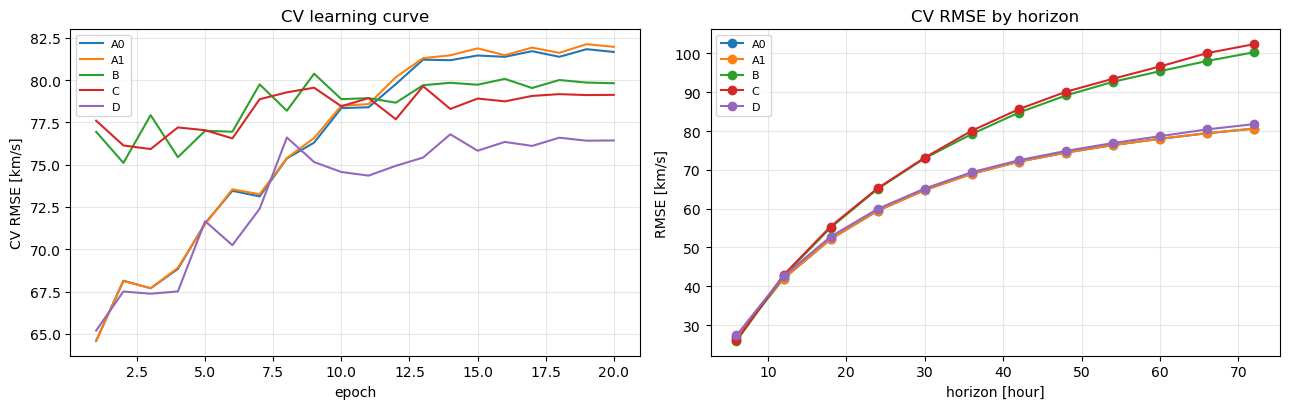

In [9]:
LADDER_FOLDS = 2        # 사다리 비교에 쓸 폴드 수. 채택 후보만 5-fold 로 재확인한다
LADDER_EPOCHS = 20      # 사다리 epoch. CNN 변형의 1폴드 실측 시간을 보고 조정할 것


def build_folds(n_folds=N_FOLDS):
    """사슬을 샘플 수가 고르게 되도록 폴드에 배정한다 (논문 Fig. 5b 의 연속 구간 배치)."""
    counts = np.bincount(TRAIN_CHAIN_ID, minlength=len(TRAIN_CHAINS))
    order = np.argsort(counts)[::-1]
    assignment = np.zeros(len(TRAIN_CHAINS), np.int64)
    loads = np.zeros(n_folds, np.int64)
    for chain in order:
        fold = int(np.argmin(loads))
        assignment[chain] = fold
        loads[fold] += counts[chain]
    return [(np.flatnonzero(assignment[TRAIN_CHAIN_ID] != f),
             np.flatnonzero(assignment[TRAIN_CHAIN_ID] == f)) for f in range(n_folds)]


FOLDS = build_folds()
print("폴드별 (학습, 평가) 샘플 수:", [(len(a), len(b)) for a, b in FOLDS])


def train_run(train_rows, evaluate_rows, seed=SEED, epochs=CV_EPOCHS, verbose=False):
    """고정 epoch 학습. 매 epoch 의 홀드아웃 horizon별 RMSE 를 기록만 한다."""
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    stats = fit_stats(train_rows)
    train_loader = make_loader(make_dataset("train", train_rows, True, stats), True, seed)
    evaluate_loader = make_loader(make_dataset("train", evaluate_rows, False, stats), False, seed)
    evaluate_targets = train_targets[evaluate_rows]

    model = build_model(stats)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                                  weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=USE_AMP)

    curve = np.zeros((epochs, 12), np.float64)
    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            moved = {k: batch[k].to(DEVICE, non_blocking=PIN_MEMORY)
                     for k in BATCH_KEYS + ("target",)}
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(DEVICE.type, enabled=USE_AMP):
                prediction = model(moved["wind_seq"], moved["wind_stats"], moved["ch_seq"],
                                   moved["ballistic"], moved["maps"], moved["last_wind"])
            loss = loss_function(prediction.float(), moved["target"])
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer); scaler.update()
        scheduler.step()
        prediction, _ = predict_with(model, evaluate_loader,
                                     stats["clip_low"], stats["clip_high"])
        curve[epoch] = official_rmse(evaluate_targets, prediction)[1]
        if verbose:
            print(f"    epoch {epoch + 1:03d} rmse {curve[epoch].mean():7.3f} "
                  f"(6h {curve[epoch][0]:5.2f} / 72h {curve[epoch][-1]:6.2f})", flush=True)
    del model, train_loader, evaluate_loader
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return curve


def run_cv(label, folds, epochs, seeds=(SEED,)):
    started = time.perf_counter()
    curves = np.zeros((len(folds), len(seeds), epochs, 12))
    for f, (train_rows, evaluate_rows) in enumerate(folds):
        for s, seed in enumerate(seeds):
            curves[f, s] = train_run(train_rows, evaluate_rows, seed, epochs)
            print(f"  fold {f + 1}/{len(folds)} seed {seed}: "
                  f"meta {curves[f, s].mean(axis=1).min():.3f} "
                  f"({time.perf_counter() - started:.0f}s)", flush=True)
    mean_curve = curves.mean(axis=(0, 1))                        # (epochs, 12)
    best_epoch = int(np.argmin(mean_curve.mean(axis=1)))
    np.save(OUTPUT_DIR / f"cv_{label}.npy", curves)
    fixed = float(mean_curve[best_epoch].mean())
    meta = float(curves.mean(axis=3).min(axis=2).mean())         # 논문 방식 (낙관 편향)
    print(f"\n[{label}] epoch {best_epoch + 1}/{epochs} | fixed {fixed:.3f} | "
          f"meta {meta:.3f} (편향 {fixed - meta:+.3f}) | "
          f"{time.perf_counter() - started:.0f}s")
    return {"curves": curves, "best_epoch": best_epoch, "mean": mean_curve,
            "fixed": fixed, "meta": meta}


# ── 사다리: 논문 두 변형 + 대조군 + 제출 후보 ──────────────────────────────
# 누적이 아니라 변형 비교다. 모든 항목이 같은 폴드를 써서 페어드로 비교된다.
ABLATION_LADDER = [
    ("A0. feature, 자전외삽 없음", dict(MODEL_VARIANT="feature", FFNN_UNITS=200,
                                        USE_ROTATION_EXTRAPOLATION=False)),
    ("A1. feature (대조군)",       dict(MODEL_VARIANT="feature", FFNN_UNITS=200,
                                        USE_ROTATION_EXTRAPOLATION=True)),
    ("B.  SpeedNet-BM (논문)",     dict(MODEL_VARIANT="bm", FFNN_UNITS=400)),
    ("C.  SpeedNet-EUV (논문)",    dict(MODEL_VARIANT="euv", FFNN_UNITS=200)),
    ("D.  hybrid (제출 후보)",     dict(MODEL_VARIANT="hybrid", FFNN_UNITS=200)),
]

LADDER = FOLDS[:LADDER_FOLDS]
VERBOSE_MODEL = True
RESULTS = []
for label, overrides in ABLATION_LADDER:
    configure(**overrides)
    print(f"\n=== {label} ===", flush=True)
    result = run_cv(label.split(".")[0].strip(), LADDER, LADDER_EPOCHS)
    result.update(label=label, settings=dict(overrides))
    RESULTS.append(result)

rows = []
for result in RESULTS:
    per_horizon = result["mean"][result["best_epoch"]]
    fold_scores = result["curves"][:, :, result["best_epoch"]].reshape(-1, 12).mean(axis=1)
    rows.append({"variant": result["label"], "epoch": result["best_epoch"] + 1,
                 "CV(fixed)": result["fixed"], "CV(meta)": result["meta"],
                 "6-36h": per_horizon[:6].mean(), "42-72h": per_horizon[6:].mean(),
                 "72h": per_horizon[-1],
                 "fold_se": fold_scores.std(ddof=1) / np.sqrt(max(len(fold_scores), 2))})
summary = pd.DataFrame(rows)
print("\n" + "=" * 96)
print(summary.round(3).to_string(index=False))
print("=" * 96)
print("판단은 CV(fixed) 로 한다. CV(meta) 는 논문 방식이고 항상 낙관적이다.")
print("fold_se 의 2배보다 작은 차이는 노이즈다 — HANDOFF §10 의 3 km/s 기준도 함께 볼 것.")
summary.to_csv(OUTPUT_DIR / "ablation.csv", index=False)

BEST = min(RESULTS, key=lambda r: r["fixed"])
configure(**BEST["settings"])
print(f"\n사다리 승자: {BEST['label']}  (CV {BEST['fixed']:.3f})")

figure, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for result in RESULTS:
    axes[0].plot(np.arange(1, LADDER_EPOCHS + 1), result["mean"].mean(axis=1),
                 label=result["label"].split(".")[0].strip())
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("CV RMSE [km/s]")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3); axes[0].set_title("CV learning curve")
for result in RESULTS:
    axes[1].plot(HORIZONS, result["mean"][result["best_epoch"]], "o-",
                 label=result["label"].split(".")[0].strip())
axes[1].set_xlabel("horizon [hour]"); axes[1].set_ylabel("RMSE [km/s]")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3); axes[1].set_title("CV RMSE by horizon")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "ablation.png", dpi=140); plt.show()

## 9. 승자 재확인 · 최종 학습

사다리는 `LADDER_FOLDS` 개 폴드로만 비교했다. 채택 후보를 **5-fold 전체**로 한 번 더 돌려
epoch 수를 확정하고, 그 epoch 로 **train 전체**에 대해 최종 학습한다.

`SUBMIT_VARIANT` 를 직접 지정하면 사다리 승자를 무시하고 그 변형으로 간다.
사다리 차이가 노이즈 수준이면 **더 단순한 쪽**을 손으로 고르라는 뜻이다 (HANDOFF §10).

validation(9월) 은 학습·통계·epoch 선택 어디에도 쓰지 않는다 (규정).

In [10]:
SUBMIT_VARIANT = None    # None 이면 사다리 승자. "hybrid" / "bm" / "euv" / "feature" 로 강제 가능
CONFIRM_FULL_CV = True   # 5-fold 재확인. CNN 변형이면 수십 분 걸린다

if SUBMIT_VARIANT is not None:
    chosen = min((r for r in RESULTS
                  if r["settings"].get("MODEL_VARIANT") == SUBMIT_VARIANT),
                 key=lambda r: r["fixed"])
else:
    chosen = BEST
configure(**chosen["settings"])
print(f"채택: {chosen['label']}")
print(json.dumps({k: str(v) for k, v in chosen["settings"].items()},
                 ensure_ascii=False, indent=2))

if CONFIRM_FULL_CV:
    confirmed = run_cv("final", FOLDS, CV_EPOCHS)
    FINAL_EPOCHS = confirmed["best_epoch"] + 1
    CV_MEAN, CV_SCORE = confirmed["mean"], confirmed["fixed"]
    SCHEDULER_TMAX = CV_EPOCHS
else:
    confirmed = chosen
    FINAL_EPOCHS = chosen["best_epoch"] + 1
    CV_MEAN, CV_SCORE = chosen["mean"], chosen["fixed"]
    SCHEDULER_TMAX = LADDER_EPOCHS
print(f"\n최종 학습: train 전체 {len(train_inputs):,} 샘플, {FINAL_EPOCHS} epoch "
      f"(CV {CV_SCORE:.3f})")
print(pd.DataFrame({"horizon": HORIZONS,
                    "cv_rmse": CV_MEAN[FINAL_EPOCHS - 1].round(2)}).to_string(index=False))

FINAL_STATS = fit_stats(np.arange(len(train_inputs)))
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

final_loader = make_loader(make_dataset("train", None, True, FINAL_STATS), True, SEED)
model = build_model(FINAL_STATS)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
# CV 와 동일한 LR 궤적을 쓰기 위해 T_max 는 CV 때 값으로 둔다 (FINAL_EPOCHS 에서 멈출 뿐이다)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=SCHEDULER_TMAX)
scaler = torch.amp.GradScaler(DEVICE.type, enabled=USE_AMP)

history = []
for epoch in range(FINAL_EPOCHS):
    started = time.perf_counter()
    model.train()
    squared_error, count = np.zeros(12), 0
    for batch in final_loader:
        moved = {k: batch[k].to(DEVICE, non_blocking=PIN_MEMORY)
                 for k in BATCH_KEYS + ("target",)}
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(DEVICE.type, enabled=USE_AMP):
            prediction = model(moved["wind_seq"], moved["wind_stats"], moved["ch_seq"],
                               moved["ballistic"], moved["maps"], moved["last_wind"])
        prediction = prediction.float()
        loss = loss_function(prediction, moved["target"])
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer); scaler.update()
        error = (prediction.detach() - moved["target"]).double()
        squared_error += torch.sum(error ** 2, dim=0).cpu().numpy()
        count += error.shape[0]
    scheduler.step()
    train_rmse = float(np.sqrt(squared_error / count).mean())
    history.append({"epoch": epoch + 1, "train_rmse": train_rmse,
                    "seconds": time.perf_counter() - started})
    print(f"epoch {epoch + 1:03d} train {train_rmse:7.3f} "
          f"lr {optimizer.param_groups[0]['lr']:.2e} "
          f"{history[-1]['seconds']:5.1f}s", flush=True)

pd.DataFrame(history).to_csv(OUTPUT_DIR / "history.csv", index=False)

채택: A0. feature, 자전외삽 없음
{
  "MODEL_VARIANT": "feature",
  "FFNN_UNITS": "200",
  "USE_ROTATION_EXTRAPOLATION": "False"
}
[feature] 맵 없음 | shared=288 head_extra=128 | ffnn=200 lstm=100
  fold 1/5 seed 777: meta 65.864 (56s)
[feature] 맵 없음 | shared=288 head_extra=128 | ffnn=200 lstm=100
  fold 2/5 seed 777: meta 63.307 (113s)
[feature] 맵 없음 | shared=288 head_extra=128 | ffnn=200 lstm=100
  fold 3/5 seed 777: meta 53.134 (170s)
[feature] 맵 없음 | shared=288 head_extra=128 | ffnn=200 lstm=100
  fold 4/5 seed 777: meta 70.200 (228s)
[feature] 맵 없음 | shared=288 head_extra=128 | ffnn=200 lstm=100
  fold 5/5 seed 777: meta 64.644 (286s)

[final] epoch 1/30 | fixed 63.630 | meta 63.430 (편향 +0.200) | 286s

최종 학습: train 전체 9,607 샘플, 1 epoch (CV 63.630)
 horizon  cv_rmse
       6    26.67
      12    41.46
      18    51.35
      24    58.53
      30    63.81
      36    67.92
      42    71.06
      48    73.44
      54    75.30
      60    76.76
      66    78.07
      72    79.19
[feature] 맵 없음 

## 10. Validation 확인 (판단용 아님) · Test 추론 · 제출물

validation 은 9월만 11블록 모인 구간이고 test 는 10~12월이다. 계절이 다르고 이미 여러 세대에 걸쳐
모델 선택에 소진됐다. 아래 표는 **확인용**이며 채택 판단은 셀 16·18 의 CV 로 끝났다.

P3 (Public 58.8028, 현재 최고 제출) 의 horizon 별 값을 나란히 둔다.
**42h~72h 에서 지지 않으면서 전체가 개선되어야** 제출 가치가 있다.

In [11]:
val_loader = make_loader(make_dataset("validation", None, False, FINAL_STATS), False)
val_prediction, val_ids = predict_with(model, val_loader,
                                       FINAL_STATS["clip_low"], FINAL_STATS["clip_high"])
assert val_ids == val_inputs.sample_id.tolist()

print("validation (판단용 아님):")
report("persistence", val_targets, PERSISTENCE_VAL, val_wind[:, -1])
val_score, val_per_horizon = report(f"P8 {MODEL_VARIANT}", val_targets, val_prediction,
                                    val_wind[:, -1])

P3_PER_HORIZON = np.array([28.35, 44.22, 53.62, 59.68, 64.32, 68.00,
                           70.64, 72.72, 74.44, 76.22, 78.20, 80.02])
comparison = pd.DataFrame({
    "horizon": HORIZONS, "P3_val": P3_PER_HORIZON, "P8_val": val_per_horizon.round(2),
    "delta": (val_per_horizon - P3_PER_HORIZON).round(2),
    "P8_cv": CV_MEAN[FINAL_EPOCHS - 1].round(2),
})
print(f"\nP3 {P3_PER_HORIZON.mean():.3f} -> P8 {val_score:.3f}  (delta 가 음수면 개선)")
print(comparison.to_string(index=False))
comparison.to_csv(OUTPUT_DIR / "validation_metrics.csv", index=False)

test_loader = make_loader(make_dataset("test", None, False, FINAL_STATS), False)
test_prediction, test_ids = predict_with(model, test_loader,
                                         FINAL_STATS["clip_low"], FINAL_STATS["clip_high"])
assert test_ids == test_inputs.sample_id.tolist()
assert test_prediction.shape == (len(test_inputs), 12) and np.isfinite(test_prediction).all()

submission = pd.DataFrame(test_prediction, columns=TARGET_COLUMNS)
submission.insert(0, "sample_id", test_inputs.sample_id.tolist())
submission.to_csv(SUBMISSION_DIR / "submission.csv", index=False)

CONFIG = {"paper": "Abraham-Alowonle et al. 2026, Earth and Space Science, 2025EA004523",
          "proj_code_version": PROJ_CODE_VERSION, "model_variant": MODEL_VARIANT,
          "map_shape": [MAP_LAT, MAP_LON], "map_channels": list(MAP_CHANNELS),
          "lat_range_deg": LAT_RANGE_DEG, "lon_range_deg": LON_RANGE_DEG, "b0_deg": B0_DEG,
          "log_mean": LOG_MEAN.tolist(), "log_std": LOG_STD.tolist(),
          "ch_cuts": list(CH_CUTS), "bright_cut": BRIGHT_CUT, "bm_channel": BM_CHANNEL,
          "fine_grid": list(FINE_GRID), "ch_grid": list(CH_GRID),
          "fold_latitude": FOLD_LATITUDE, "used_levels": list(USE_LEVELS),
          "transit_speeds": list(TRANSIT_SPEEDS),
          "reference_transit_hours": REFERENCE_TRANSIT_HOURS,
          "ballistic_source": BALLISTIC_SOURCE, "ballistic_offsets": list(BALLISTIC_OFFSETS),
          "meridian_half_width_deg": MERIDIAN_HALF_WIDTH_DEG,
          "rotation_extrapolation": USE_ROTATION_EXTRAPOLATION,
          "speednet_filters": list(SPEEDNET_FILTERS), "lstm_units": LSTM_UNITS,
          "ffnn_units": FFNN_UNITS, "dropout": DROPOUT, "residual_output": RESIDUAL_OUTPUT,
          "paper_faithful": PAPER_FAITHFUL, "loss_kind": LOSS_KIND,
          "batch_size": BATCH_SIZE, "learning_rate": LEARNING_RATE,
          "weight_decay": WEIGHT_DECAY, "seed": SEED, "epochs": FINAL_EPOCHS,
          "cv_rmse": float(CV_SCORE), "val_rmse": float(val_score),
          "initialization": "random_from_scratch",
          **{k: (v.tolist() if isinstance(v, np.ndarray) else v)
             for k, v in FINAL_STATS.items()}}
torch.save({"model_state_dict": model.state_dict(), **CONFIG}, SUBMISSION_DIR / "model.pth")
print(f"\nsubmission.csv {submission.shape}, model.pth 저장 완료")
print(submission[TARGET_COLUMNS].describe().loc[["mean", "std", "min", "max"]].round(1))

validation (판단용 아님):
persistence              RMSE  84.105 | r 0.560 | TS 0.000 | 6h  30.13 72h 110.93
P8 feature               RMSE  66.772 | r 0.680 | TS 0.155 | 6h  29.73 72h  81.54

P3 64.203 -> P8 66.772  (delta 가 음수면 개선)
 horizon  P3_val  P8_val  delta  P8_cv
       6   28.35   29.73   1.38  26.67
      12   44.22   46.13   1.91  41.46
      18   53.62   55.76   2.14  51.35
      24   59.68   62.15   2.47  58.53
      30   64.32   67.13   2.81  63.81
      36   68.00   71.09   3.09  67.92
      42   70.64   74.07   3.43  71.06
      48   72.72   76.12   3.40  73.44
      54   74.44   77.79   3.35  75.30
      60   76.22   79.24   3.02  76.76
      66   78.20   80.50   2.30  78.07
      72   80.02   81.54   1.52  79.19

submission.csv (3868, 13), model.pth 저장 완료
      target_00  target_01  target_02  target_03  target_04  target_05  \
mean      407.8      408.8      409.5      410.5      411.1      412.1   
std        80.3       73.9       69.7       66.5       64.7       63.1   


## 11. Grad-CAM 귀인 진단 (논문 §3.1, Eq. 5–6)

$$\alpha_k = \frac{1}{Z}\sum_i\sum_j \frac{\partial y}{\partial A^k_{ij}}, \qquad
L_{\text{Grad-CAM}} = \mathrm{ReLU}\Big(\sum_k \alpha_k A^k\Big)$$

논문의 결론은 **모델이 중앙자오선 ±10° 의 중·저위도 코로나홀을 본다**는 것이었다.
경위도 맵에서는 그게 세로 밴드 하나이므로 숫자로 확인할 수 있다.

**이 셀은 제출물에 영향이 없다.** 학습된 모델이 물리적으로 말이 되는 곳을 보는지만 확인한다.
밴드 안팎 비가 1 근처면 모델이 코로나홀이 아니라 다른 것(전역 밝기 등)을 보고 있다는 뜻이다.

In [12]:
def grad_cam(model, batch, horizon_index):
    """논문 Eq. 5-6. 마지막 Conv 활성에 대한 (B, 20, h, w) CAM 을 돌려준다."""
    model.eval()
    moved = {k: batch[k].to(DEVICE) for k in BATCH_KEYS}
    activations = {}

    def hook(_module, _inputs, output):
        output.retain_grad()
        activations["value"] = output

    handle = model.backbone.blocks[-1].register_forward_hook(hook)
    try:
        # cuDNN 은 eval 모드의 RNN backward 를 지원하지 않는다. 이 블록에서만 끈다.
        with torch.backends.cudnn.flags(enabled=False):
            prediction = model(moved["wind_seq"], moved["wind_stats"], moved["ch_seq"],
                               moved["ballistic"], moved["maps"], moved["last_wind"])
            model.zero_grad(set_to_none=True)
            prediction[:, horizon_index].sum().backward()
        feature = activations["value"]                    # (B*20, K, h, w)
        alpha = feature.grad.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((alpha * feature).sum(dim=1))        # (B*20, h, w)
    finally:
        handle.remove()
    return cam.detach().float().view(len(moved["maps"]), 20, *cam.shape[-2:]).cpu().numpy()


if USES_MAP[MODEL_VARIANT]:
    probe_loader = make_loader(make_dataset("validation", None, False, FINAL_STATS), False)
    probe_batch = next(iter(probe_loader))
    cam = grad_cam(model, probe_batch, horizon_index=11)          # 72h
    heat = cam.mean(axis=(0, 1))                                  # (h, w)
    heat = np.asarray(Image.fromarray(heat).resize((MAP_LON, MAP_LAT), Image.BILINEAR))
    heat = heat / (heat.max() + 1e-12)

    band = np.abs(MAP_LON_DEG) <= MERIDIAN_HALF_WIDTH_DEG
    low_latitude = np.abs(MAP_LAT_DEG) <= 30.0
    inside = heat[np.ix_(low_latitude, band)].mean()
    outside = heat[np.ix_(low_latitude, ~band)].mean()
    print(f"중앙자오선 +-{MERIDIAN_HALF_WIDTH_DEG:.0f}° / 저위도 |lat|<=30° 평균 활성: "
          f"{inside:.4f}")
    print(f"그 밖(같은 위도대) 평균 활성:                          {outside:.4f}")
    print(f"비율 {inside / (outside + 1e-12):.2f}  "
          f"(1 보다 크면 논문 §4.3 의 중앙자오선 지배 결론과 일치)")

    figure, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
    extent = [-LON_RANGE_DEG, LON_RANGE_DEG, -LAT_RANGE_DEG, LAT_RANGE_DEG]
    frame = np.asarray(probe_batch["maps"][0, -1], np.float32).mean(axis=0)
    axes[0].imshow(frame, extent=extent, origin="lower", aspect="auto", cmap="gray")
    axes[0].set_title("Stonyhurst map, last frame (mean over channels)")
    axes[1].imshow(heat, extent=extent, origin="lower", aspect="auto", cmap="inferno")
    axes[1].set_title("Grad-CAM, 72h horizon (mean over batch and frames)")
    for axis in axes:
        for edge in (-MERIDIAN_HALF_WIDTH_DEG, MERIDIAN_HALF_WIDTH_DEG):
            axis.axvline(edge, color="red", linewidth=1.0)
        axis.set_ylabel("heliographic latitude [deg]")
    axes[1].set_xlabel("heliographic longitude [deg]")
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / "gradcam.png", dpi=140); plt.show()
else:
    print(f"variant={MODEL_VARIANT} 은 맵 입력이 없어 Grad-CAM 대상이 아니다.")

variant=feature 은 맵 입력이 없어 Grad-CAM 대상이 아니다.


## 12. 제출 점검

`submission/` 아래 `code.ipynb`, `model.pth`, `submission.csv` 세 파일이 필요하다.

> ⚠️ `code.ipynb` 는 **수동 복사**다. 이 노트북을 저장(Ctrl+S)한 뒤 `submission/code.ipynb` 로
> 복사할 것. 코드를 고칠 때마다 다시 복사해야 한다.

> ⚠️ **P3(Public 58.8028)를 이기지 못하면 제출하지 말 것.** 하루 5회 제한이고 최종 순위는
> Public + Private 합산이다. 셀 16 CV 에서 `feature` 대조군을 유의하게 이기지 못했다면
> 이 노트북의 결과물은 보관만 하고 P3 을 유지한다.

In [13]:
EXPECTED_TEST_ROWS = 3868
ok = True
for name in ["code.ipynb", "model.pth", "submission.csv"]:
    path = SUBMISSION_DIR / name
    if path.exists():
        print(f"  {name:16s} {path.stat().st_size / 1024 ** 2:8.2f} MiB")
    else:
        print(f"  {name:16s} 없음"); ok = False

check = pd.read_csv(SUBMISSION_DIR / "submission.csv")
ok &= len(check) == EXPECTED_TEST_ROWS
ok &= list(check.columns) == ["sample_id"] + TARGET_COLUMNS
ok &= check.sample_id.tolist() == test_inputs.sample_id.tolist()
ok &= int(check.isna().sum().sum()) == 0
values = check[TARGET_COLUMNS].to_numpy()
ok &= bool((values >= FINAL_STATS["clip_low"] - 1e-6).all()
           and (values <= FINAL_STATS["clip_high"] + 1e-6).all())
print(f"\n행 수 {len(check)} / 결측 {int(check.isna().sum().sum())} / "
      f"값 범위 {values.min():.1f} ~ {values.max():.1f}")
print(f"CV {CV_SCORE:.3f} | validation {val_score:.3f} | P3 Public 58.8028 (현재 최고 제출)")
print("최종:", "통과" if ok else "실패 — 위 항목 확인")

  code.ipynb       없음
  model.pth            1.18 MiB
  submission.csv       0.88 MiB

행 수 3868 / 결측 0 / 값 범위 266.4 ~ 748.1
CV 63.630 | validation 66.772 | P3 Public 58.8028 (현재 최고 제출)
최종: 실패 — 위 항목 확인
